In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
import textwrap
 
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
pd.set_option('display.max_colwidth', 100)
 
# --- KONFIGURASI: sesuaikan keyword ini jika nama file Anda berbeda ---
# Auto-discovery mencari file di /kaggle/input yang NAMANYA MENGANDUNG keyword ini
# (case-insensitive). Kalau salah ambil file atau tidak ketemu, isi path lengkap
# secara manual, contoh:
#   path_inflasi = '/kaggle/input/nama-dataset-anda/inflasi_bulanan.csv'
KEYWORD_INFLASI   = 'inflasi'
KEYWORD_IHPR_2002 = '2002'
KEYWORD_IHPR_2018 = '2018'
KEYWORD_PDB       = 'pdb'
KEYWORD_BI_RATE   = 'rate'
KEYWORD_SENSUS    = 'sensus'
 
KAGGLE_INPUT_DIR  = '/kaggle/input'
KAGGLE_OUTPUT_DIR = '/kaggle/working'
 
 
def find_file(keyword, base_dir=KAGGLE_INPUT_DIR):
    """Cari file di base_dir yang namanya mengandung 'keyword' (case-insensitive)."""
    matches = []
    for root, _, files in os.walk(base_dir):
        for f in files:
            if keyword.lower() in f.lower():
                matches.append(os.path.join(root, f))
    if len(matches) == 0:
        raise FileNotFoundError(
            f"Tidak ada file mengandung kata '{keyword}' di {base_dir}.\n"
            f"-> Cek nama file dataset Kaggle Anda, lalu isi path manual di bagian CONFIG."
        )
    if len(matches) > 1:
        print(f"⚠️  Ditemukan {len(matches)} file cocok utk keyword '{keyword}', memakai yang pertama:")
        for m in matches:
            print(f"    - {m}")
    return matches[0]
 
 
def smart_read(path):
    low = path.lower()
    if low.endswith('.csv'):
        try:
            df = pd.read_csv(path)
            if df.shape[1] == 1:
                df = pd.read_csv(path, sep=';')
            return df
        except Exception:
            return pd.read_csv(path, sep=';')
    elif low.endswith(('.xlsx', '.xls')):
        return pd.read_excel(path)
    raise ValueError(f"Ekstensi file tidak dikenali: {path}")
 
 
def cek_jumlah_kolom(df, expected_n, name):
    """
    Peringatan dini jika jumlah kolom yang terbaca tidak sesuai ekspektasi.
    Penyebab paling umum: ada KOMA di dalam value (misal nama Komponen PDB
    seperti 'Pertanian, Kehutanan, Dan Perikanan') yang tidak terquote
    dengan benar di file CSV asli, sehingga kolom jadi bergeser/pecah.
    """
    if df.shape[1] != expected_n:
        print(f"⚠️  [{name}] Jumlah kolom terbaca = {df.shape[1]}, ekspektasi = {expected_n}.\n"
              f"    Kemungkinan ada koma di dalam value yang tidak terquote benar di file sumber.\n"
              f"    Kolom yang terbaca: {list(df.columns)}")
    else:
        print(f"✅ [{name}] Jumlah kolom sesuai ekspektasi ({expected_n}).")
 
 
def parse_id_comma_decimal(series):
    """
    Format Indonesia: titik = pemisah ribuan, koma = desimal.
    Contoh: '108,66' -> 108.66 ; '1.234,56' -> 1234.56
    Dipakai untuk: IHPR (kedua basis), PDB.
    """
    s = series.copy()
    mask_na = s.isna()
    s = s.astype(str).str.strip()
    s = s.str.replace('.', '', regex=False).str.replace(',', '.', regex=False)
    out = pd.to_numeric(s, errors='coerce')
    out[mask_na] = np.nan
    return out
 
 
def parse_plain_decimal(series):
    """
    Angka format standar (titik = desimal, tanpa pemisah ribuan).
    Contoh: '-0.15' -> -0.15 ; '2523198' -> 2523198
    Dipakai untuk: Inflasi, Sensus.
    """
    s = series.copy()
    mask_na = s.isna()
    s = s.astype(str).str.strip()
    out = pd.to_numeric(s, errors='coerce')
    out[mask_na] = np.nan
    return out
 
 
def parse_percent(series):
    """
    String persen, contoh '5.50 %' -> 5.50 (satuan PERSEN, bukan desimal 0.055).
    Dipakai untuk: BI Rate.
    """
    s = series.copy()
    mask_na = s.isna()
    s = s.astype(str).str.strip().str.replace('%', '', regex=False).str.strip()
    out = pd.to_numeric(s, errors='coerce')
    out[mask_na] = np.nan
    return out
 
 
BULAN_MAP = {
    'januari': 1, 'februari': 2, 'maret': 3, 'april': 4,
    'mei': 5, 'juni': 6, 'juli': 7, 'agustus': 8,
    'september': 9, 'oktober': 10, 'november': 11, 'desember': 12,
}
 
 
def normalize_quarter(value):
    """
    Menyamakan notasi kuartal yang berbeda antar dataset:
      - IHPR pakai romawi : QI, QII, QIII, QIV
      - PDB   pakai angka : Q1, Q2, Q3, Q4
    Mengembalikan integer 1-4 (atau NaN jika tidak terbaca).
    """
    if pd.isna(value):
        return np.nan
    v = str(value).strip().upper().replace(' ', '')
    roman = {'QI': 1, 'QII': 2, 'QIII': 3, 'QIV': 4}
    arabic = {'Q1': 1, 'Q2': 2, 'Q3': 3, 'Q4': 4}
    if v in roman:
        return roman[v]
    if v in arabic:
        return arabic[v]
    digits = ''.join(ch for ch in v if ch.isdigit())
    return int(digits) if digits else np.nan

def periode_sortkey(p):
    """
    Urutkan string periode 'YYYY-QN' secara kronologis, bukan alfabetis.
    Dipindah ke sini (setup awal) supaya tersedia dari CELL 10 (Viz Stage 2)
    sampai CELL 12 (Stage 3), bukan cuma di satu tempat -- lihat catatan bug
    di CELL 10 (periode_terbaru).
    """
    y, q = p.split('-Q')
    return (int(y), int(q))

def format_wrapped_list(values, width=100, indent=8):
    """
    Mengubah list nilai menjadi teks berbaris agar mudah dibaca.
    """
    if len(values) == 0:
        return "(kosong)"
    text = " | ".join(str(v) for v in values)
    return textwrap.fill(text, width=width, subsequent_indent=" " * indent)

def profile_dataframe(df, name, show_all_unique_for_object=True):
    """
    Profil dataset yang lengkap dan enak dibaca manusia.

    Output:
    1) Ringkasan dataset
    2) Tabel ringkas per kolom
    3) Detail per kolom dalam blok terpisah
    """
    print("\n" + "=" * 100)
    print(f"PROFIL DATASET: {name}")
    print(f"Jumlah baris : {len(df):,}")
    print(f"Jumlah kolom : {len(df.columns):,}")
    print("=" * 100)

    # TABEL RINGKAS
    summary_rows = []
    for col in df.columns:
        s = df[col]
        n_unique = int(s.nunique(dropna=True))
        n_missing = int(s.isna().sum())
        pct_missing = (n_missing / len(df) * 100) if len(df) else 0
        dtype = str(s.dtype)

        if pd.api.types.is_numeric_dtype(s):
            detail_type = "numerik"
        elif pd.api.types.is_datetime64_any_dtype(s):
            detail_type = "tanggal"
        else:
            detail_type = "kategori"

        summary_rows.append({
            "kolom": col,
            "dtype": dtype,
            "jenis": detail_type,
            "unique": n_unique,
            "missing": n_missing,
            "missing_%": round(pct_missing, 2),
        })

    summary_df = pd.DataFrame(summary_rows)
    print("\nRINGKASAN KOLOM")
    print("-" * 100)
    display(summary_df)

    # DETAIL PER KOLOM
    print("\nDETAIL PER KOLOM")
    print("-" * 100)

    for col in df.columns:
        s = df[col]
        n_unique = int(s.nunique(dropna=True))
        n_missing = int(s.isna().sum())
        pct_missing = (n_missing / len(df) * 100) if len(df) else 0
        dtype = str(s.dtype)

        print("\n" + "─" * 100)
        print(f"KOLom: {col}")
        print(f"  dtype      : {dtype}")
        print(f"  unique     : {n_unique:,}")
        print(f"  missing    : {n_missing:,} ({pct_missing:.2f}%)")

        # NUMERIK
        if pd.api.types.is_numeric_dtype(s):
            desc = s.describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95])
            print("  statistik  :")
            print(f"    count    = {desc.get('count', np.nan):,.0f}")
            print(f"    mean     = {desc.get('mean', np.nan):.6f}")
            print(f"    std      = {desc.get('std', np.nan):.6f}")
            print(f"    min      = {desc.get('min', np.nan):.6f}")
            print(f"    5%       = {desc.get('5%', np.nan):.6f}")
            print(f"    25%      = {desc.get('25%', np.nan):.6f}")
            print(f"    50%      = {desc.get('50%', np.nan):.6f}")
            print(f"    75%      = {desc.get('75%', np.nan):.6f}")
            print(f"    95%      = {desc.get('95%', np.nan):.6f}")
            print(f"    max      = {desc.get('max', np.nan):.6f}")

            # contoh nilai numerik unik
            uniq_vals = s.dropna().unique()
            if len(uniq_vals) <= 20:
                print("  nilai unik :")
                print("    " + format_wrapped_list(sorted(uniq_vals.tolist()), width=90, indent=6))
            else:
                sampel = sorted(uniq_vals.tolist())[:20]
                print("  nilai unik :")
                print("    " + format_wrapped_list(sampel, width=90, indent=6))
                print(f"    ... dan {len(uniq_vals) - 20:,} nilai unik lainnya")

        # TANGGAL
        elif pd.api.types.is_datetime64_any_dtype(s):
            print("  rentang    :")
            print(f"    min      = {s.min()}")
            print(f"    max      = {s.max()}")

            sampel = s.dropna().sort_values().astype(str).unique().tolist()[:12]
            if len(sampel) > 0:
                print("  contoh     :")
                print("    " + format_wrapped_list(sampel, width=90, indent=6))

        # KATEGORI / TEKS
        else:
            uniq_vals = s.dropna().astype(str).unique().tolist()

            print("  nilai unik :")
            if show_all_unique_for_object or len(uniq_vals) <= 40:
                # tampilkan semua nilai unik, tapi dibungkus baris agar mudah dibaca
                if len(uniq_vals) == 0:
                    print("    (tidak ada)")
                else:
                    try:
                        uniq_vals = sorted(uniq_vals)
                    except Exception:
                        pass
                    print("    " + format_wrapped_list(uniq_vals, width=90, indent=6))
            else:
                # kalau terlalu banyak, tampilkan sebagian besar + info sisanya
                preview = uniq_vals[:40]
                print("    " + format_wrapped_list(preview, width=90, indent=6))
                print(f"    ... dan {len(uniq_vals) - 40:,} nilai unik lainnya")

    print("\n" + "=" * 100)
    return summary_df
 
print("Setup selesai. Lanjut ke CELL 2 untuk memproses dataset Inflasi.")

Setup selesai. Lanjut ke CELL 2 untuk memproses dataset Inflasi.


Membaca: /kaggle/input/datasets/dbernardons/dataset-investasi-property/inflasi bulanan index 2022  100.csv
✅ [Inflasi] Jumlah kolom sesuai ekspektasi (4).

PROFIL DATASET: Inflasi_Bulanan
Jumlah baris : 1,368
Jumlah kolom : 6

RINGKASAN KOLOM
----------------------------------------------------------------------------------------------------


,kolom,dtype,jenis,unique,missing,missing_%
0,Provinsi,object,kategori,38,0,0.00
1,Tahun,Int64,numerik,3,0,0.00
2,Bulan,object,kategori,12,0,0.00
3,Nilai,float64,numerik,274,266,19.44
4,bulan_num,int64,numerik,12,0,0.00
5,tanggal,datetime64[ns],tanggal,36,0,0.00



DETAIL PER KOLOM
----------------------------------------------------------------------------------------------------

────────────────────────────────────────────────────────────────────────────────────────────────────
KOLom: Provinsi
  dtype      : object
  unique     : 38
  missing    : 0 (0.00%)
  nilai unik :
    Aceh | Bali | Banten | Bengkulu | Di Yogyakarta | Dki Jakarta | Gorontalo | Jambi | Jawa
      Barat | Jawa Tengah | Jawa Timur | Kalimantan Barat | Kalimantan Selatan |
      Kalimantan Tengah | Kalimantan Timur | Kalimantan Utara | Kepulauan Bangka Belitung
      | Kepulauan Riau | Lampung | Maluku | Maluku Utara | Nusa Tenggara Barat | Nusa
      Tenggara Timur | Papua | Papua Barat | Papua Barat Daya | Papua Pegunungan | Papua
      Selatan | Papua Tengah | Riau | Sulawesi Barat | Sulawesi Selatan | Sulawesi Tengah
      | Sulawesi Tenggara | Sulawesi Utara | Sumatera Barat | Sumatera Selatan | Sumatera
      Utara

───────────────────────────────────────────────────

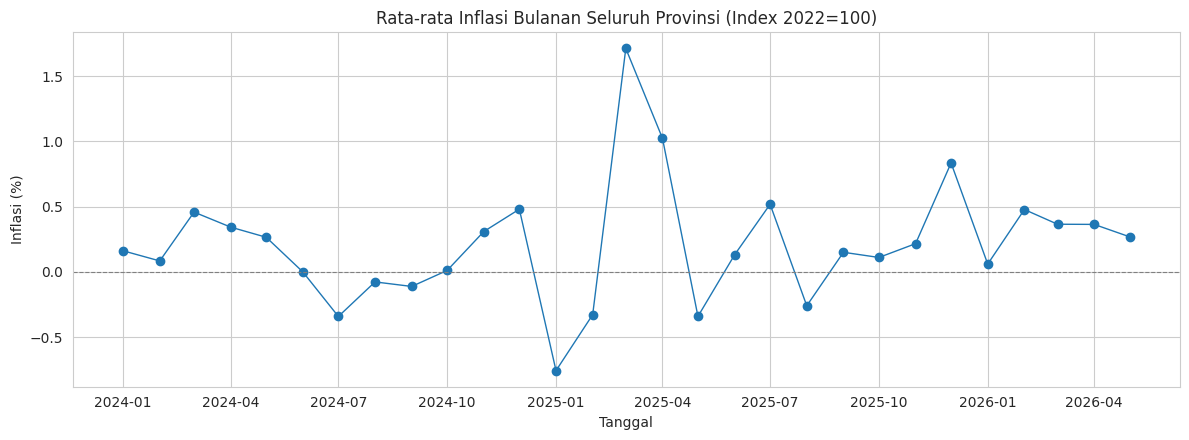

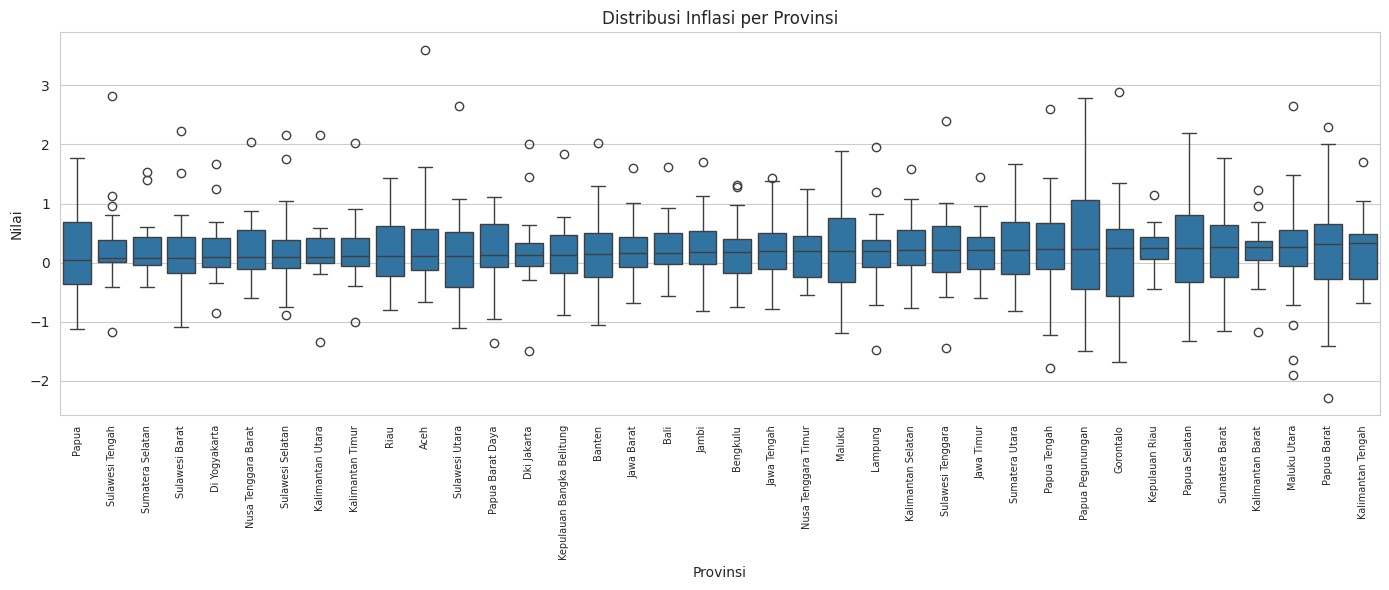

CELL 2 selesai. Lanjut ke CELL 3 untuk unifikasi IHPR.


In [2]:
path_inflasi = find_file(KEYWORD_INFLASI)
print(f"Membaca: {path_inflasi}")
df_inflasi = smart_read(path_inflasi)
df_inflasi.columns = [c.strip() for c in df_inflasi.columns]
cek_jumlah_kolom(df_inflasi, 4, 'Inflasi')
 
df_inflasi['Provinsi'] = df_inflasi['Provinsi'].astype(str).str.strip()
df_inflasi['Tahun'] = pd.to_numeric(df_inflasi['Tahun'], errors='coerce').astype('Int64')
df_inflasi['bulan_num'] = df_inflasi['Bulan'].astype(str).str.strip().str.lower().map(BULAN_MAP)
df_inflasi['Nilai'] = parse_plain_decimal(df_inflasi['Nilai'])   # format contoh: '-0.15' (titik desimal)
 
tmp = pd.DataFrame({'year': df_inflasi['Tahun'], 'month': df_inflasi['bulan_num'], 'day': 1})
df_inflasi['tanggal'] = pd.to_datetime(tmp, errors='coerce')
 
bulan_tak_terbaca = df_inflasi[df_inflasi['bulan_num'].isna() & df_inflasi['Bulan'].notna()]
if len(bulan_tak_terbaca) > 0:
    print(f"⚠️  {len(bulan_tak_terbaca)} baris dengan nama bulan tidak terbaca:",
          bulan_tak_terbaca['Bulan'].unique())
 
profil_inflasi = profile_dataframe(df_inflasi, 'Inflasi_Bulanan')
 
# --- visualisasi 1: tren rata-rata nasional ---
plt.figure(figsize=(12, 4.5))
agg = df_inflasi.groupby('tanggal')['Nilai'].mean().reset_index()
plt.plot(agg['tanggal'], agg['Nilai'], marker='o', linewidth=1)
plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)
plt.title('Rata-rata Inflasi Bulanan Seluruh Provinsi (Index 2022=100)')
plt.xlabel('Tanggal'); plt.ylabel('Inflasi (%)')
plt.tight_layout(); plt.show()
 
# --- visualisasi 2: distribusi inflasi per provinsi ---
plt.figure(figsize=(14, 6))
order = df_inflasi.groupby('Provinsi')['Nilai'].median().sort_values().index
sns.boxplot(data=df_inflasi, x='Provinsi', y='Nilai', order=order)
plt.xticks(rotation=90, fontsize=7)
plt.title('Distribusi Inflasi per Provinsi')
plt.tight_layout(); plt.show()
 
print("CELL 2 selesai. Lanjut ke CELL 3 untuk unifikasi IHPR.")

Membaca basis 2002=100: /kaggle/input/datasets/dbernardons/dataset-investasi-property/IHPR property index 2002  100.csv
Membaca basis 2018=100: /kaggle/input/datasets/dbernardons/dataset-investasi-property/IHPR property index 2018  100.csv
✅ [IHPR_2002] Jumlah kolom sesuai ekspektasi (5).
✅ [IHPR_2018] Jumlah kolom sesuai ekspektasi (5).

PROFIL DATASET: IHPR_basis_2002
Jumlah baris : 972
Jumlah kolom : 7

RINGKASAN KOLOM
----------------------------------------------------------------------------------------------------


,kolom,dtype,jenis,unique,missing,missing_%
0,Kota,object,kategori,18,0,0.00
1,Tipe,object,kategori,3,0,0.00
2,Tahun,Int64,numerik,5,0,0.00
3,Kuartal,object,kategori,4,0,0.00
4,Nilai,float64,numerik,784,18,1.85
5,kuartal_num,int64,numerik,4,0,0.00
6,basis,object,kategori,1,0,0.00



DETAIL PER KOLOM
----------------------------------------------------------------------------------------------------

────────────────────────────────────────────────────────────────────────────────────────────────────
KOLom: Kota
  dtype      : object
  unique     : 18
  missing    : 0 (0.00%)
  nilai unik :
    Balikpapan | Bandar Lampung | Bandung | Banjarmasin | Batam | Denpasar | Jabodebek-Banten
      | Makassar | Manado | Medan | Padang | Palembang | Pekanbaru | Pontianak | Samarinda
      | Semarang | Surabaya | Yogyakarta

────────────────────────────────────────────────────────────────────────────────────────────────────
KOLom: Tipe
  dtype      : object
  unique     : 3
  missing    : 0 (0.00%)
  nilai unik :
    Besar | Kecil | Menengah

────────────────────────────────────────────────────────────────────────────────────────────────────
KOLom: Tahun
  dtype      : Int64
  unique     : 5
  missing    : 0 (0.00%)
  statistik  :
    count    = 972
    mean     = 2019.777778


,kolom,dtype,jenis,unique,missing,missing_%
0,Kota,object,kategori,18,0,0.0
1,Tipe,object,kategori,3,0,0.0
2,Tahun,Int64,numerik,5,0,0.0
3,Kuartal,object,kategori,4,0,0.0
4,Nilai,float64,numerik,584,0,0.0
5,kuartal_num,int64,numerik,4,0,0.0
6,basis,object,kategori,1,0,0.0



DETAIL PER KOLOM
----------------------------------------------------------------------------------------------------

────────────────────────────────────────────────────────────────────────────────────────────────────
KOLom: Kota
  dtype      : object
  unique     : 18
  missing    : 0 (0.00%)
  nilai unik :
    Balikpapan | Bandar Lampung | Bandung | Banjarmasin | Batam | Denpasar | Jabodebek-Banten
      | Makassar | Manado | Medan | Padang | Palembang | Pekanbaru | Pontianak | Samarinda
      | Semarang | Surabaya | Yogyakarta

────────────────────────────────────────────────────────────────────────────────────────────────────
KOLom: Tipe
  dtype      : object
  unique     : 3
  missing    : 0 (0.00%)
  nilai unik :
    Besar | Kecil | Menengah

────────────────────────────────────────────────────────────────────────────────────────────────────
KOLom: Tahun
  dtype      : Int64
  unique     : 5
  missing    : 0 (0.00%)
  statistik  :
    count    = 918
    mean     = 2023.647059


,kolom,dtype,jenis,unique,missing,missing_%
0,Kota,object,kategori,18,0,0.00
1,Tipe,object,kategori,3,0,0.00
2,Tahun,Int64,numerik,9,0,0.00
3,kuartal_num,int64,numerik,4,0,0.00
4,periode,object,kategori,33,0,0.00
5,Nilai_unifikasi,float64,numerik,1294,18,1.01
6,sumber_baris,object,kategori,2,0,0.00



DETAIL PER KOLOM
----------------------------------------------------------------------------------------------------

────────────────────────────────────────────────────────────────────────────────────────────────────
KOLom: Kota
  dtype      : object
  unique     : 18
  missing    : 0 (0.00%)
  nilai unik :
    Balikpapan | Bandar Lampung | Bandung | Banjarmasin | Batam | Denpasar | Jabodebek-Banten
      | Makassar | Manado | Medan | Padang | Palembang | Pekanbaru | Pontianak | Samarinda
      | Semarang | Surabaya | Yogyakarta

────────────────────────────────────────────────────────────────────────────────────────────────────
KOLom: Tipe
  dtype      : object
  unique     : 3
  missing    : 0 (0.00%)
  nilai unik :
    Besar | Kecil | Menengah

────────────────────────────────────────────────────────────────────────────────────────────────────
KOLom: Tahun
  dtype      : Int64
  unique     : 9
  missing    : 0 (0.00%)
  statistik  :
    count    = 1,782
    mean     = 2021.63636

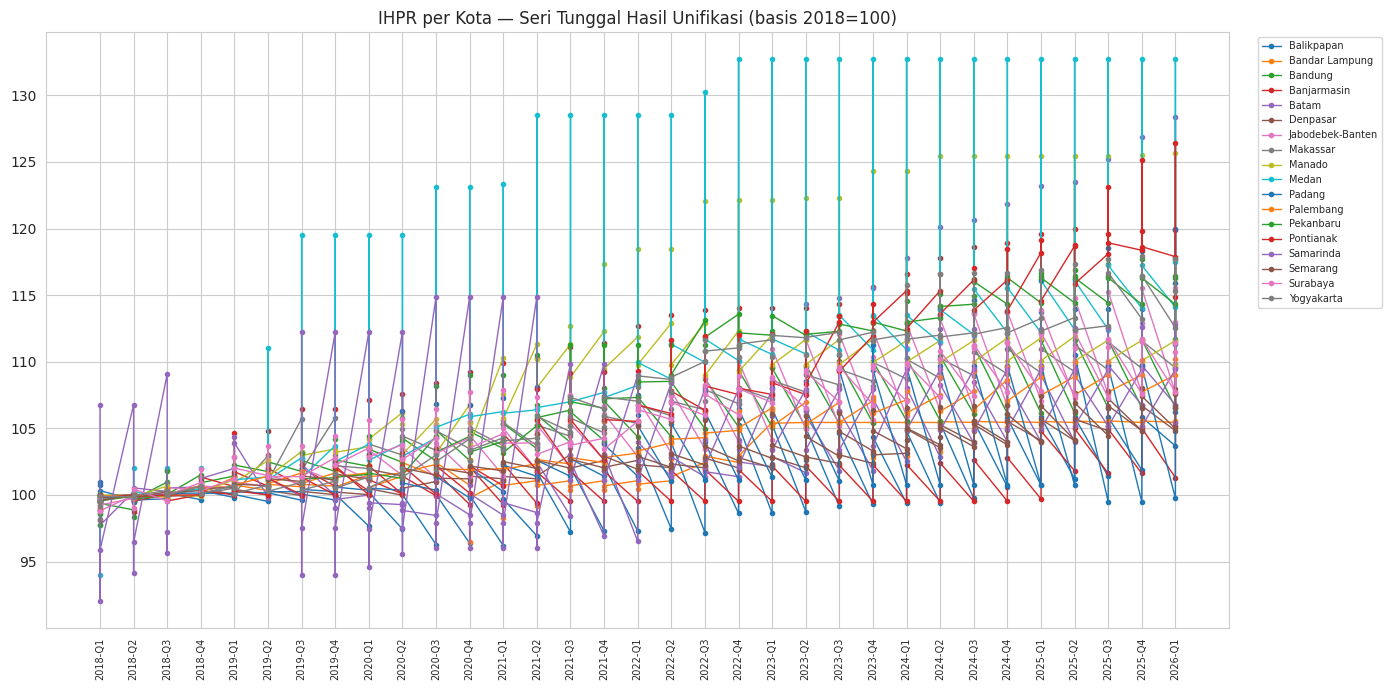

CELL 3 selesai. Lanjut ke CELL 4 untuk dataset PDB.


In [3]:
path_ihpr_2002 = find_file(KEYWORD_IHPR_2002)
path_ihpr_2018 = find_file(KEYWORD_IHPR_2018)
print(f"Membaca basis 2002=100: {path_ihpr_2002}")
print(f"Membaca basis 2018=100: {path_ihpr_2018}")
 
df_old = smart_read(path_ihpr_2002)
df_new = smart_read(path_ihpr_2018)
 
for df_, nm in [(df_old, 'IHPR_2002'), (df_new, 'IHPR_2018')]:
    df_.columns = [c.strip() for c in df_.columns]
    cek_jumlah_kolom(df_, 5, nm)
    df_['Kota'] = df_['Kota'].astype(str).str.strip().str.title()
    df_['Tipe'] = df_['Tipe'].astype(str).str.strip().str.title()
    df_['Tahun'] = pd.to_numeric(df_['Tahun'], errors='coerce').astype('Int64')
    df_['kuartal_num'] = df_['Kuartal'].apply(normalize_quarter)
    df_['Nilai'] = parse_id_comma_decimal(df_['Nilai'])   # format contoh: '108,66' (koma desimal)
 
df_old['basis'] = '2002=100'
df_new['basis'] = '2018=100'
 
profil_ihpr_2002 = profile_dataframe(df_old, 'IHPR_basis_2002')
profil_ihpr_2018 = profile_dataframe(df_new, 'IHPR_basis_2018')
 
# --- cari titik overlap (Kota, Tipe, Tahun, kuartal) yang ada di KEDUA basis ---
key_cols = ['Kota', 'Tipe', 'Tahun', 'kuartal_num']
overlap = pd.merge(
    df_old[key_cols + ['Nilai']].rename(columns={'Nilai': 'nilai_lama'}),
    df_new[key_cols + ['Nilai']].rename(columns={'Nilai': 'nilai_baru'}),
    on=key_cols, how='inner'
)
print(f"\nJumlah titik overlap antar dua basis: {len(overlap)}")
 
profil_ihpr_unified = pd.DataFrame()  # default kosong, diisi jika overlap ditemukan
 
if len(overlap) > 0:
    # --- hitung faktor konversi PER Kota+Tipe (beda kota = beda faktor, ini wajar) ---
    overlap['faktor_konversi'] = overlap['nilai_baru'] / overlap['nilai_lama']
    faktor = (overlap.groupby(['Kota', 'Tipe'])['faktor_konversi']
              .agg(['mean', 'std', 'count']).reset_index())
    print("\nFaktor konversi per Kota & Tipe (std mendekati 0 = konsisten antar titik overlap):")
    print(faktor.to_string(index=False))
 
    df_old_2 = df_old.merge(
        faktor[['Kota', 'Tipe', 'mean']].rename(columns={'mean': 'faktor_konversi'}),
        on=['Kota', 'Tipe'], how='left'
    )
    df_old_2['nilai_basis2018'] = df_old_2['Nilai'] * df_old_2['faktor_konversi']
 
    n_gagal = int(df_old_2['faktor_konversi'].isna().sum())
    if n_gagal > 0:
        print(f"⚠️  {n_gagal} baris basis lama tanpa faktor konversi "
              f"(kombinasi Kota+Tipe tidak ada di titik overlap) -> tidak dikonversi (NaN).")
 
    df_old_2['periode'] = df_old_2['Tahun'].astype(str) + '-Q' + df_old_2['kuartal_num'].astype('Int64').astype(str)
    df_new['periode'] = df_new['Tahun'].astype(str) + '-Q' + df_new['kuartal_num'].astype('Int64').astype(str)
 
    # KUNCI KOMPOSIT (Kota+Tipe+periode), BUKAN periode saja — supaya dedup
    # benar per kota/tipe, bukan kebetulan match periode antar kota lain.
    df_old_2['kunci'] = df_old_2['Kota'] + '|' + df_old_2['Tipe'] + '|' + df_old_2['periode']
    df_new['kunci'] = df_new['Kota'] + '|' + df_new['Tipe'] + '|' + df_new['periode']
    kunci_baru = set(df_new['kunci'])
 
    # ambil bagian basis lama yang TIDAK bertumpang dgn basis baru (periode sebelum transisi)
    df_old_unik = df_old_2[~df_old_2['kunci'].isin(kunci_baru)].copy()
    df_old_unik['Nilai_unifikasi'] = df_old_unik['nilai_basis2018']
    df_old_unik['sumber_baris'] = 'rescaled_dari_2002=100'
 
    df_new_unik = df_new.copy()
    df_new_unik['Nilai_unifikasi'] = df_new_unik['Nilai']
    df_new_unik['sumber_baris'] = 'asli_2018=100'
 
    kolom_final = ['Kota', 'Tipe', 'Tahun', 'kuartal_num', 'periode', 'Nilai_unifikasi', 'sumber_baris']
    ihpr_unified = (pd.concat([df_old_unik[kolom_final], df_new_unik[kolom_final]], ignore_index=True)
                     .sort_values(['Kota', 'Tipe', 'Tahun', 'kuartal_num'])
                     .reset_index(drop=True))
 
    # --- validasi otomatis: pastikan tidak ada duplikasi periode per Kota+Tipe ---
    dup_check = ihpr_unified.groupby(['Kota', 'Tipe', 'periode']).size()
    if (dup_check > 1).any():
        print("⚠️  PERINGATAN: ditemukan duplikasi periode setelah unifikasi pada kombinasi berikut:")
        print(dup_check[dup_check > 1])
    else:
        print("✅ Validasi: tidak ada duplikasi periode setelah unifikasi.")
 
    print(f"\n✅ ihpr_unified berhasil dibuat: {len(ihpr_unified)} baris, basis tunggal mengikuti 2018=100.")
    profil_ihpr_unified = profile_dataframe(ihpr_unified, 'IHPR_unified')
 
else:
    print("\n⚠️  TIDAK ADA TITIK OVERLAP antara dua basis. Penyambungan otomatis TIDAK dilakukan "
          "(prinsip: jangan memaksakan hasil tanpa dasar yang valid). Kedua basis digabung apa "
          "adanya dengan kolom 'basis' sebagai penanda — perlu penyambungan manual jika diperlukan.")
    for df_, label in [(df_old, 'asli_2002=100 (TIDAK rescaled - tidak ada overlap)'),
                        (df_new, 'asli_2018=100')]:
        df_['periode'] = df_['Tahun'].astype(str) + '-Q' + df_['kuartal_num'].astype('Int64').astype(str)
        df_['Nilai_unifikasi'] = df_['Nilai']
        df_['sumber_baris'] = label
    kolom_final = ['Kota', 'Tipe', 'Tahun', 'kuartal_num', 'periode', 'Nilai_unifikasi', 'sumber_baris']
    ihpr_unified = pd.concat([df_old[kolom_final], df_new[kolom_final]], ignore_index=True)
 
# --- visualisasi: tren IHPR per kota (basis tunggal hasil unifikasi) ---
plt.figure(figsize=(14, 7))
tipe_tersedia = [t.lower() for t in ihpr_unified['Tipe'].dropna().unique()]
plot_df = ihpr_unified[ihpr_unified['Tipe'].str.lower() == 'total'] if 'total' in tipe_tersedia else ihpr_unified
 
for kota, grp in plot_df.groupby('Kota'):
    g = grp.sort_values(['Tahun', 'kuartal_num'])
    plt.plot(g['periode'], g['Nilai_unifikasi'], marker='.', linewidth=1, label=kota)
 
plt.xticks(rotation=90, fontsize=7)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=7)
plt.title('IHPR per Kota — Seri Tunggal Hasil Unifikasi (basis 2018=100)')
plt.tight_layout(); plt.show()
 
print("CELL 3 selesai. Lanjut ke CELL 4 untuk dataset PDB.")

Membaca: /kaggle/input/datasets/dbernardons/dataset-investasi-property/(Seri 2010) Laju Pertumbuhan PDB Seri 2010 2020-2026.csv
✅ [PDB] Jumlah kolom sesuai ekspektasi (6).

PROFIL DATASET: PDB_Laju_Pertumbuhan
Jumlah baris : 5,208
Jumlah kolom : 8

RINGKASAN KOLOM
----------------------------------------------------------------------------------------------------


,kolom,dtype,jenis,unique,missing,missing_%
0,Komponen,object,kategori,62,0,0.00
1,Level,object,kategori,3,0,0.00
2,Laju_Pertumbuhan,object,kategori,3,0,0.00
3,Tahun,Int64,numerik,7,0,0.00
4,Kuartal,object,kategori,4,0,0.00
5,Nilai,float64,numerik,2056,558,10.71
6,kuartal_num,int64,numerik,4,0,0.00
7,periode,object,kategori,28,0,0.00



DETAIL PER KOLOM
----------------------------------------------------------------------------------------------------

────────────────────────────────────────────────────────────────────────────────────────────────────
KOLom: Komponen
  dtype      : object
  unique     : 62
  missing    : 0 (0.00%)
  nilai unik :
    Administrasi Pemerintahan, Pertahanan Dan Jaminan Sosial Wajib | Angkutan Darat | Angkutan
      Laut | Angkutan Rel | Angkutan Sungai Danau Dan Penyeberangan | Angkutan Udara |
      Asuransi Dan Dana Pensiun | Industri Alat Angkutan | Industri Barang Galian Bukan
      Logam | Industri Barang Logam; Komputer, Barang Elektronik, Optik; Dan Peralatan
      Listrik | Industri Batubara Dan Pengilangan Migas | Industri Furnitur | Industri
      Karet, Barang Dari Karet Dan Plastik | Industri Kayu, Barang Dari Kayu Dan Gabus Dan
      Barang Anyaman Dari Bambu, Rotan Dan Sejenisnya | Industri Kertas Dan Barang Dari
      Kertas; Percetakan Dan Reproduksi Media Rekaman | Indu

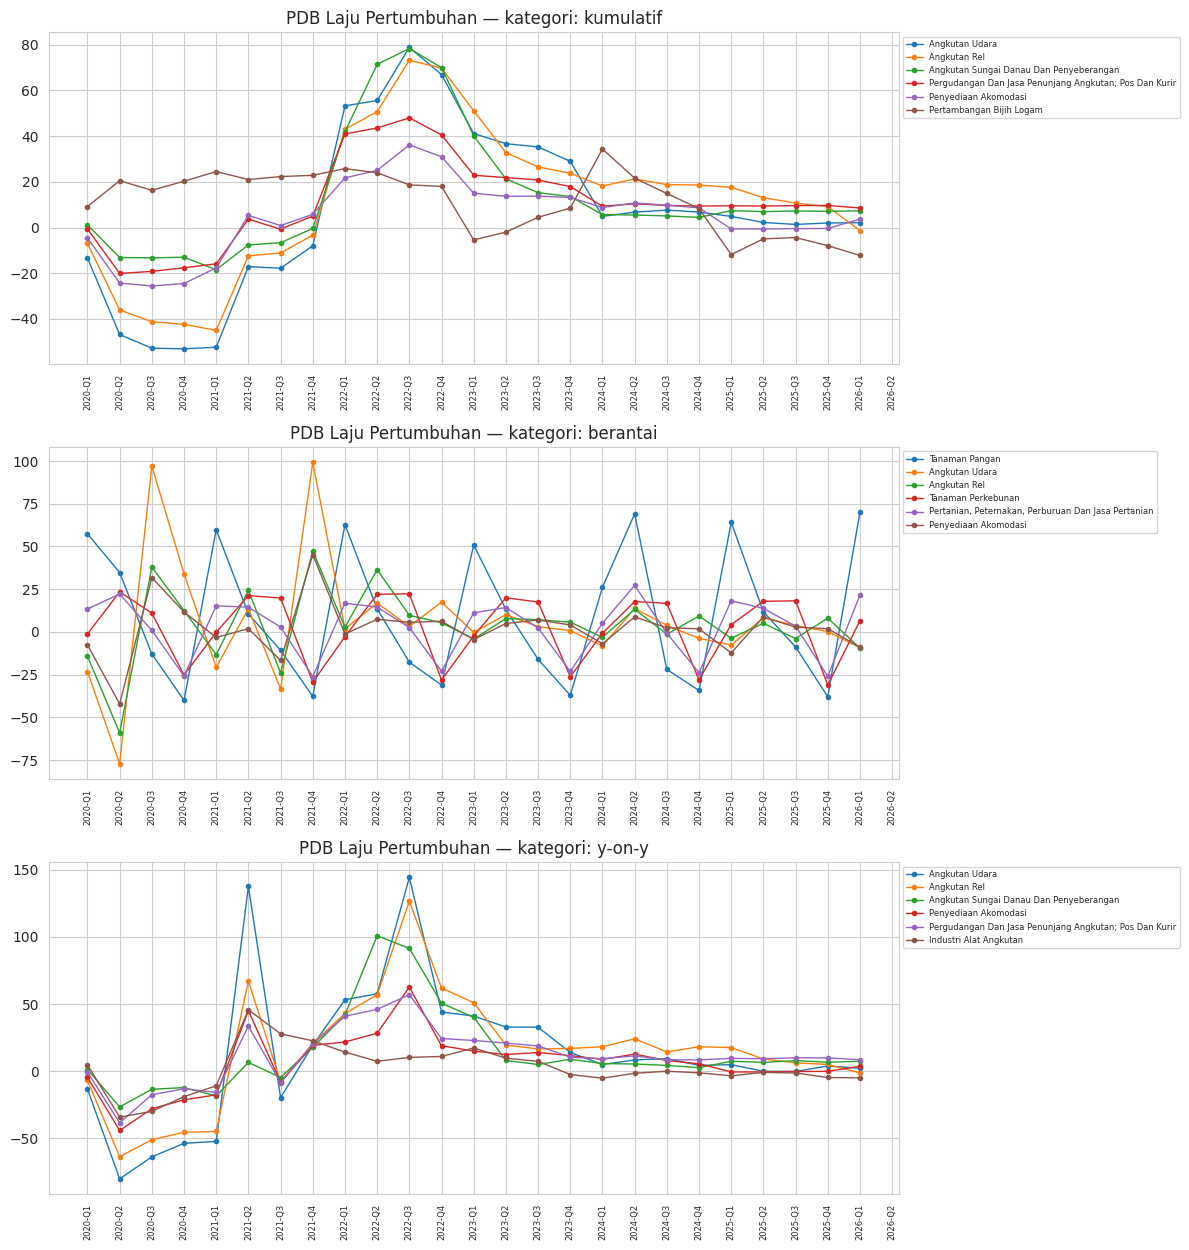

CELL 4 selesai. Lanjut ke CELL 5 untuk dataset BI Rate.


In [4]:
path_pdb = find_file(KEYWORD_PDB)
print(f"Membaca: {path_pdb}")
df_pdb = smart_read(path_pdb)
df_pdb.columns = [c.strip() for c in df_pdb.columns]
cek_jumlah_kolom(df_pdb, 6, 'PDB')   # cek krusial: koma di "Pertanian, Kehutanan, Dan Perikanan" harus terquote benar
 
df_pdb['Komponen'] = df_pdb['Komponen'].astype(str).str.strip()
df_pdb['Level'] = df_pdb['Level'].astype(str).str.strip().str.lower()
df_pdb['Laju_Pertumbuhan'] = df_pdb['Laju_Pertumbuhan'].astype(str).str.strip().str.lower()
df_pdb['Tahun'] = pd.to_numeric(df_pdb['Tahun'], errors='coerce').astype('Int64')
df_pdb['kuartal_num'] = df_pdb['Kuartal'].apply(normalize_quarter)
df_pdb['Nilai'] = parse_id_comma_decimal(df_pdb['Nilai'])   # format contoh: '0,03' (koma desimal)
df_pdb['periode'] = df_pdb['Tahun'].astype(str) + '-Q' + df_pdb['kuartal_num'].astype('Int64').astype(str)
 
profil_pdb = profile_dataframe(df_pdb, 'PDB_Laju_Pertumbuhan')
 
print("\n📌 PENTING: kategori 'Laju_Pertumbuhan' yang tersedia — pilih SATU basis yang konsisten "
      "(biasanya yang berarti year-on-year) saat dibandingkan dengan IHPR YoY / Inflasi YoY, "
      "agar tidak salah mencampur basis pertumbuhan kumulatif/q-to-q/y-on-y:")
print(df_pdb['Laju_Pertumbuhan'].value_counts())
 
# --- visualisasi: 6 sektor paling fluktuatif, per kategori laju pertumbuhan ---
kategori_list = df_pdb['Laju_Pertumbuhan'].dropna().unique().tolist()
fig, axes = plt.subplots(len(kategori_list), 1, figsize=(12, 4.2 * len(kategori_list)))
if len(kategori_list) == 1:
    axes = [axes]
 
for ax, kategori in zip(axes, kategori_list):
    grp = df_pdb[df_pdb['Laju_Pertumbuhan'] == kategori]
    top_sektor = grp.groupby('Komponen')['Nilai'].std().sort_values(ascending=False).head(6).index
    for sektor in top_sektor:
        s = grp[grp['Komponen'] == sektor].sort_values(['Tahun', 'kuartal_num'])
        ax.plot(s['periode'], s['Nilai'], marker='.', linewidth=1, label=sektor)
    ax.set_title(f"PDB Laju Pertumbuhan — kategori: {kategori}")
    ax.tick_params(axis='x', rotation=90, labelsize=6)
    ax.legend(fontsize=6, loc='upper left', bbox_to_anchor=(1.0, 1.0))
 
plt.tight_layout(); plt.show()
 
print("CELL 4 selesai. Lanjut ke CELL 5 untuk dataset BI Rate.")

Membaca: /kaggle/input/datasets/dbernardons/dataset-investasi-property/BI Rate.csv
✅ [BI_Rate] Jumlah kolom sesuai ekspektasi (2).
✅ Validasi tanggal: tidak ada baris bertanggal masa depan (asumsi dayfirst=True konsisten).

PROFIL DATASET: BI_Rate
Jumlah baris : 124
Jumlah kolom : 4

RINGKASAN KOLOM
----------------------------------------------------------------------------------------------------


,kolom,dtype,jenis,unique,missing,missing_%
0,Tanggal,object,kategori,124,0,0.0
1,BI_Rate_raw,object,kategori,12,0,0.0
2,tanggal,datetime64[ns],tanggal,124,0,0.0
3,BI_Rate,float64,numerik,12,0,0.0



DETAIL PER KOLOM
----------------------------------------------------------------------------------------------------

────────────────────────────────────────────────────────────────────────────────────────────────────
KOLom: Tanggal
  dtype      : object
  unique     : 124
  missing    : 0 (0.00%)
  nilai unik :
    09/06/2026 | 10/02/2022 | 13/10/2020 | 14/04/2020 | 14/12/2017 | 15/01/2025 | 15/02/2018 |
      15/06/2017 | 15/08/2018 | 15/11/2018 | 15/12/2016 | 16/02/2017 | 16/02/2023 |
      16/03/2017 | 16/03/2023 | 16/05/2019 | 16/06/2016 | 16/07/2020 | 16/07/2025 |
      16/10/2024 | 16/11/2017 | 16/12/2021 | 17/01/2019 | 17/01/2024 | 17/03/2022 |
      17/03/2026 | 17/05/2018 | 17/06/2021 | 17/07/2024 | 17/09/2020 | 17/09/2025 |
      17/11/2016 | 17/11/2022 | 17/12/2020 | 17/12/2025 | 18/01/2018 | 18/02/2021 |
      18/03/2021 | 18/04/2023 | 18/05/2017 | 18/06/2020 | 18/06/2025 | 18/07/2019 |
      18/09/2024 | 18/11/2021 | 18/12/2024 | 19/01/2017 | 19/01/2023 | 19/02/2025 |


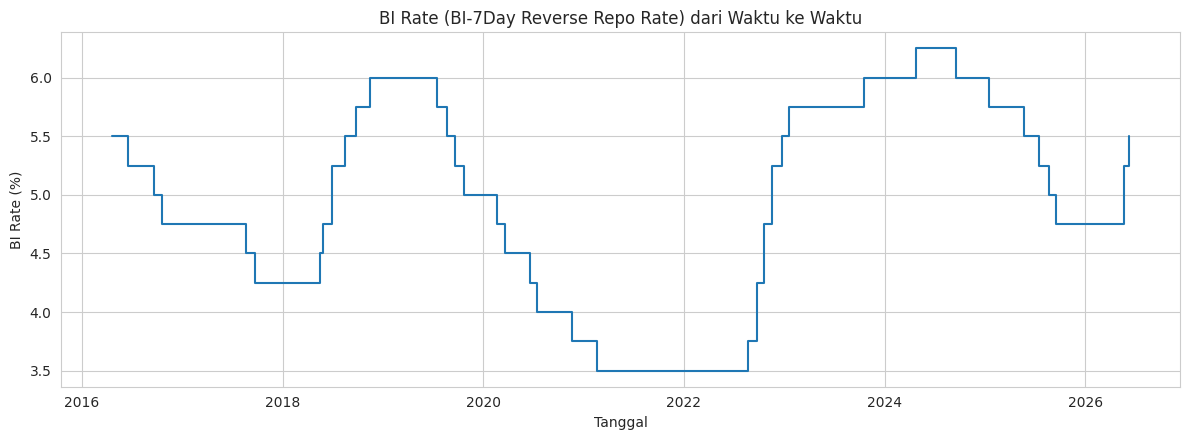

CELL 5 selesai. Lanjut ke CELL 6 untuk dataset Sensus.


In [5]:
path_bi = find_file(KEYWORD_BI_RATE)
print(f"Membaca: {path_bi}")
df_bi = smart_read(path_bi)
df_bi.columns = [c.strip() for c in df_bi.columns]
cek_jumlah_kolom(df_bi, 2, 'BI_Rate')
 
kolom_rate_cands = [c for c in df_bi.columns if 'rr' in c.lower() or 'rate' in c.lower()]
if not kolom_rate_cands:
    raise KeyError("Kolom suku bunga tidak ditemukan — cek nama kolomnya di file BI Rate Anda.")
df_bi = df_bi.rename(columns={kolom_rate_cands[0]: 'BI_Rate_raw'})
 
# CATATAN ASUMSI: format tanggal diasumsikan DD/MM/YYYY (dayfirst=True, konvensi Indonesia).
df_bi['tanggal'] = pd.to_datetime(df_bi['Tanggal'], dayfirst=True, errors='coerce')
df_bi['BI_Rate'] = parse_percent(df_bi['BI_Rate_raw'])   # format contoh: '5.50 %'
 
# --- self-check: kalau ada tanggal "di masa depan", asumsi dayfirst kemungkinan salah ---
cek_masa_depan = df_bi[df_bi['tanggal'] > pd.Timestamp.today()]
if len(cek_masa_depan) > 0:
    print(f"⚠️  {len(cek_masa_depan)} baris bertanggal masa depan setelah parsing dayfirst=True.\n"
          f"    Asumsi format DD/MM/YYYY mungkin SALAH (mungkin sebenarnya MM/DD/YYYY) — cek baris ini:")
    print(cek_masa_depan[['Tanggal', 'tanggal']].head())
else:
    print("✅ Validasi tanggal: tidak ada baris bertanggal masa depan (asumsi dayfirst=True konsisten).")
 
profil_bi = profile_dataframe(df_bi, 'BI_Rate')
 
plt.figure(figsize=(12, 4.5))
df_bi_sorted = df_bi.sort_values('tanggal')
plt.step(df_bi_sorted['tanggal'], df_bi_sorted['BI_Rate'], where='post')
plt.title('BI Rate (BI-7Day Reverse Repo Rate) dari Waktu ke Waktu')
plt.xlabel('Tanggal'); plt.ylabel('BI Rate (%)')
plt.tight_layout(); plt.show()
 
print("CELL 5 selesai. Lanjut ke CELL 6 untuk dataset Sensus.")

Membaca: /kaggle/input/datasets/dbernardons/dataset-investasi-property/Sensus Penduduk 2020.csv
✅ [Sensus] Jumlah kolom sesuai ekspektasi (5).

PROFIL DATASET: Sensus_2020
Jumlah baris : 136
Jumlah kolom : 5

RINGKASAN KOLOM
----------------------------------------------------------------------------------------------------


,kolom,dtype,jenis,unique,missing,missing_%
0,Provinsi,object,kategori,34,0,0.0
1,Tahun,Int64,numerik,1,0,0.0
2,Status,object,kategori,2,0,0.0
3,Gender,object,kategori,2,0,0.0
4,Nilai,int64,numerik,136,0,0.0



DETAIL PER KOLOM
----------------------------------------------------------------------------------------------------

────────────────────────────────────────────────────────────────────────────────────────────────────
KOLom: Provinsi
  dtype      : object
  unique     : 34
  missing    : 0 (0.00%)
  nilai unik :
    Aceh | Bali | Banten | Bengkulu | Di Yogyakarta | Dki Jakarta | Gorontalo | Jambi | Jawa
      Barat | Jawa Tengah | Jawa Timur | Kalimantan Barat | Kalimantan Selatan |
      Kalimantan Tengah | Kalimantan Timur | Kalimantan Utara | Kepulauan Bangka Belitung
      | Kepulauan Riau | Lampung | Maluku | Maluku Utara | Nusa Tenggara Barat | Nusa
      Tenggara Timur | Papua | Papua Barat | Riau | Sulawesi Barat | Sulawesi Selatan |
      Sulawesi Tengah | Sulawesi Tenggara | Sulawesi Utara | Sumatera Barat | Sumatera
      Selatan | Sumatera Utara

────────────────────────────────────────────────────────────────────────────────────────────────────
KOLom: Tahun
  dtype     

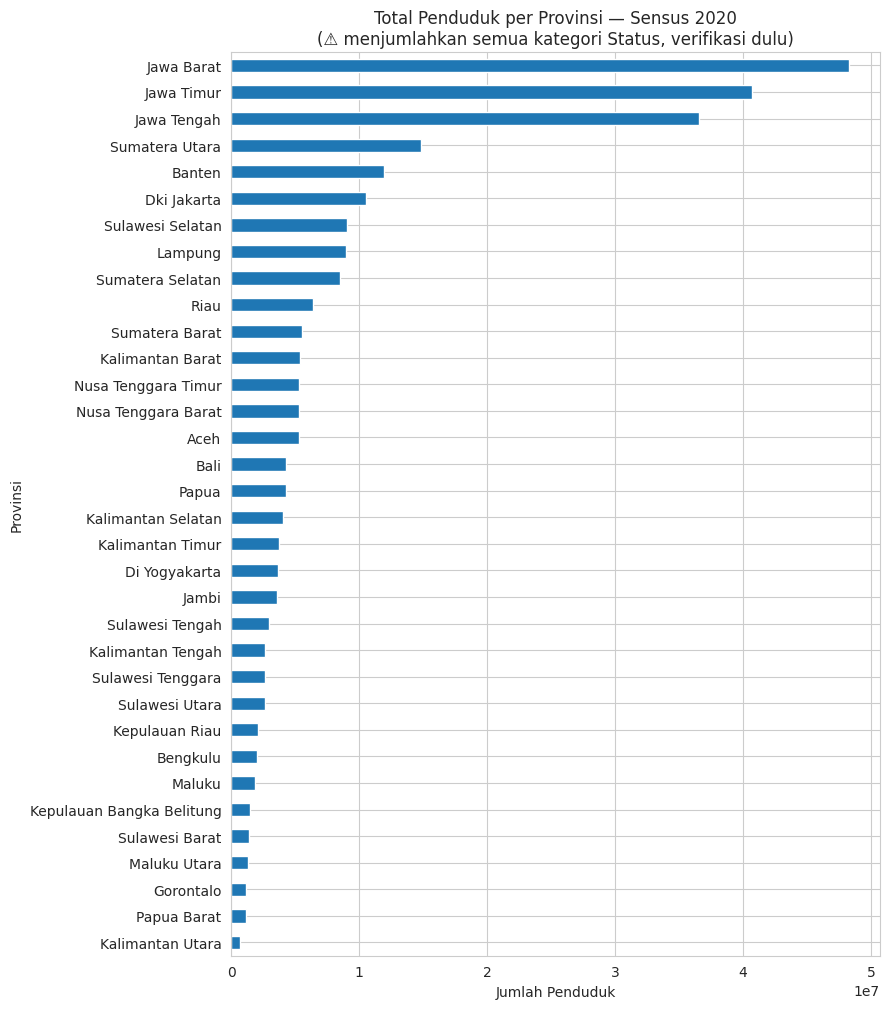

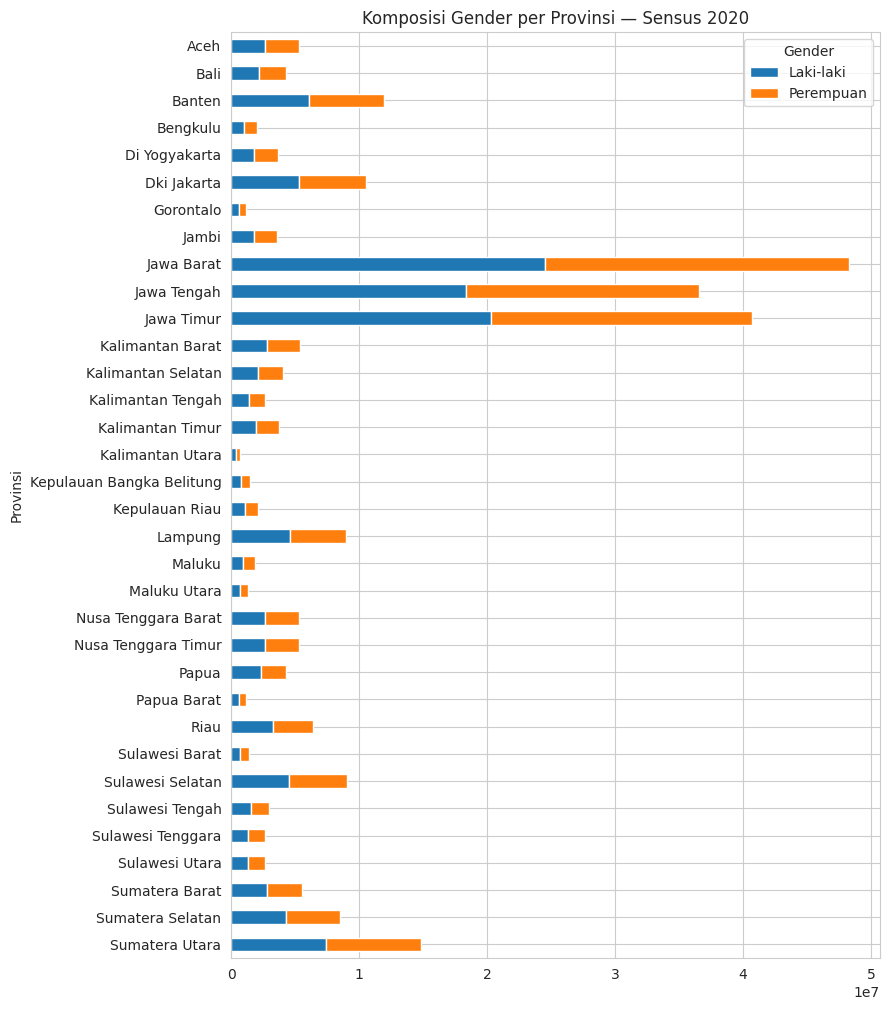

CELL 6 selesai. Lanjut ke CELL 7 untuk export semua profil.


In [6]:
path_sensus = find_file(KEYWORD_SENSUS)
print(f"Membaca: {path_sensus}")
df_sensus = smart_read(path_sensus)
df_sensus.columns = [c.strip() for c in df_sensus.columns]
cek_jumlah_kolom(df_sensus, 5, 'Sensus')
 
df_sensus['Provinsi'] = df_sensus['Provinsi'].astype(str).str.strip()
df_sensus['Status'] = df_sensus['Status'].astype(str).str.strip()
df_sensus['Gender'] = df_sensus['Gender'].astype(str).str.strip()
df_sensus['Tahun'] = pd.to_numeric(df_sensus['Tahun'], errors='coerce').astype('Int64')
df_sensus['Nilai'] = parse_plain_decimal(df_sensus['Nilai'])
 
profil_sensus = profile_dataframe(df_sensus, 'Sensus_2020')
 
print("\n📌 PENTING: kategori kolom 'Status' berikut perlu DIVERIFIKASI maknanya ke dokumentasi "
      "BPS SEBELUM menjumlahkan Nilai per Provinsi (supaya tidak double count / under count populasi):")
print(df_sensus['Status'].value_counts())
 
# --- visualisasi: total penduduk per provinsi (menjumlahkan SEMUA kategori Status -- lihat catatan di atas) ---
pop_provinsi = df_sensus.groupby('Provinsi')['Nilai'].sum().sort_values(ascending=False)
plt.figure(figsize=(9, max(4, 0.3 * len(pop_provinsi))))
pop_provinsi.plot(kind='barh')
plt.title('Total Penduduk per Provinsi — Sensus 2020\n(⚠️ menjumlahkan semua kategori Status, verifikasi dulu)')
plt.xlabel('Jumlah Penduduk')
plt.gca().invert_yaxis()
plt.tight_layout(); plt.show()
 
# --- visualisasi: komposisi gender per provinsi ---
pop_gender = df_sensus.groupby(['Provinsi', 'Gender'])['Nilai'].sum().unstack()
pop_gender.plot(kind='barh', stacked=True, figsize=(9, max(4, 0.3 * len(pop_gender))))
plt.title('Komposisi Gender per Provinsi — Sensus 2020')
plt.gca().invert_yaxis()
plt.tight_layout(); plt.show()
 
print("CELL 6 selesai. Lanjut ke CELL 7 untuk export semua profil.")

In [7]:
semua_profil = pd.concat(
    [profil_inflasi, profil_ihpr_2002, profil_ihpr_2018, profil_ihpr_unified,
     profil_pdb, profil_bi, profil_sensus],
    ignore_index=True
)
 
semua_profil.to_csv(f'{KAGGLE_OUTPUT_DIR}/profil_semua_dataset.csv', index=False)
df_inflasi.to_csv(f'{KAGGLE_OUTPUT_DIR}/inflasi_clean.csv', index=False)
ihpr_unified.to_csv(f'{KAGGLE_OUTPUT_DIR}/ihpr_unified.csv', index=False)
df_pdb.to_csv(f'{KAGGLE_OUTPUT_DIR}/pdb_clean.csv', index=False)
df_bi.to_csv(f'{KAGGLE_OUTPUT_DIR}/bi_rate_clean.csv', index=False)
df_sensus.to_csv(f'{KAGGLE_OUTPUT_DIR}/sensus_clean.csv', index=False)
 
print(f"""
✅ SELESAI. File tersimpan di {KAGGLE_OUTPUT_DIR}/:
 
   profil_semua_dataset.csv   <- Isinya ringkasan unique value semua kolom, semua dataset
   inflasi_clean.csv
   ihpr_unified.csv           <- IHPR dua basis sudah disatukan jadi satu seri
   pdb_clean.csv
   bi_rate_clean.csv
   sensus_clean.csv
 
Langkah selanjutnya: download profil_semua_dataset.csv dari tab "Output" notebook ini,
lalu tempelkan isinya (atau upload file-nya) kembali ke percakapan.
""")


✅ SELESAI. File tersimpan di /kaggle/working/:
 
   profil_semua_dataset.csv   <- Isinya ringkasan unique value semua kolom, semua dataset
   inflasi_clean.csv
   ihpr_unified.csv           <- IHPR dua basis sudah disatukan jadi satu seri
   pdb_clean.csv
   bi_rate_clean.csv
   sensus_clean.csv
 
Langkah selanjutnya: download profil_semua_dataset.csv dari tab "Output" notebook ini,
lalu tempelkan isinya (atau upload file-nya) kembali ke percakapan.



In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
 
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams.update({'figure.dpi': 110, 'font.size': 9})
 
# ── 8A: Mapping manual Kota (IHPR) → Provinsi (Inflasi/Sensus) ─────────
# Jabodebek-Banten: entitas multi-provinsi, DKI Jakarta dipakai sebagai proxy
# Balikpapan & Samarinda: sama-sama Kalimantan Timur
KOTA_TO_PROVINSI = {
    'Bandung':          'Jawa Barat',
    'Bandar Lampung':   'Lampung',
    'Banjarmasin':      'Kalimantan Selatan',
    'Balikpapan':       'Kalimantan Timur',
    'Batam':            'Kepulauan Riau',
    'Denpasar':         'Bali',
    'Jabodebek-Banten': 'Dki Jakarta',
    'Makassar':         'Sulawesi Selatan',
    'Manado':           'Sulawesi Utara',
    'Medan':            'Sumatera Utara',
    'Padang':           'Sumatera Barat',
    'Palembang':        'Sumatera Selatan',
    'Pekanbaru':        'Riau',
    'Pontianak':        'Kalimantan Barat',
    'Samarinda':        'Kalimantan Timur',
    'Semarang':         'Jawa Tengah',
    'Surabaya':         'Jawa Timur',
    'Yogyakarta':       'Di Yogyakarta',
}
 
# ── 8B: Basis ekonomi per kota → untuk korelasi dengan sektor PDB ──────
# Catatan: ini adalah pemetaan INTERPRETATIF berdasarkan sektor dominan
# Anda bebas menyesuaikan sesuai pengetahuan lokal Anda
KOTA_BASIS_EKONOMI = {
    'Bandung':          'Industri Tekstil Dan Pakaian Jadi',
    'Bandar Lampung':   'Pertanian, Kehutanan, Dan Perikanan',
    'Banjarmasin':      'Perdagangan Besar Dan Eceran; Reparasi Mobil Dan Sepeda Motor',
    'Balikpapan':       'Pertambangan Minyak, Gas Dan Panas Bumi',
    'Batam':            'Industri Pengolahan',
    'Denpasar':         'Penyediaan Akomodasi Dan Makan Minum',
    'Jabodebek-Banten': 'Jasa Keuangan Dan Asuransi',
    'Makassar':         'Perdagangan Besar Dan Eceran; Reparasi Mobil Dan Sepeda Motor',
    'Manado':           'Penyediaan Akomodasi Dan Makan Minum',
    'Medan':            'Perdagangan Besar Dan Eceran; Reparasi Mobil Dan Sepeda Motor',
    'Padang':           'Pertanian, Kehutanan, Dan Perikanan',
    'Palembang':        'Pertambangan Minyak, Gas Dan Panas Bumi',
    'Pekanbaru':        'Pertambangan Minyak, Gas Dan Panas Bumi',
    'Pontianak':        'Pertanian, Kehutanan, Dan Perikanan',
    'Samarinda':        'Pertambangan Batubara Dan Lignit',
    'Semarang':         'Industri Pengolahan',
    'Surabaya':         'Perdagangan Besar Dan Eceran; Reparasi Mobil Dan Sepeda Motor',
    'Yogyakarta':       'Jasa Pendidikan',
}
 
# validasi: semua kota di IHPR punya mapping
kota_ihpr = set(ihpr_unified['Kota'].unique())
kota_prov_keys = set(KOTA_TO_PROVINSI.keys())
kota_basis_keys = set(KOTA_BASIS_EKONOMI.keys())
missing_prov  = kota_ihpr - kota_prov_keys
missing_basis = kota_ihpr - kota_basis_keys
if missing_prov:
    print(f'⚠️  Kota tanpa mapping Provinsi: {missing_prov} — tambahkan ke KOTA_TO_PROVINSI')
if missing_basis:
    print(f'⚠️  Kota tanpa basis ekonomi: {missing_basis} — tambahkan ke KOTA_BASIS_EKONOMI')
if not missing_prov and not missing_basis:
    print('✅ Semua mapping kota lengkap')
 
 
# ── 8C: IHPR — tambah kolom Provinsi & hitung YoY ──────────────────────
ihpr_w = ihpr_unified.copy()
ihpr_w['Provinsi'] = ihpr_w['Kota'].map(KOTA_TO_PROVINSI)
ihpr_w['basis_sektor'] = ihpr_w['Kota'].map(KOTA_BASIS_EKONOMI)
ihpr_w = ihpr_w.sort_values(['Kota', 'Tipe', 'Tahun', 'kuartal_num']).reset_index(drop=True)
 
# IHPR YoY: (indeks_t − indeks_{t-4}) / indeks_{t-4} × 100
# groupby Kota+Tipe memastikan tidak bocor antar kota atau tipe
ihpr_w['ihpr_yoy'] = (
    ihpr_w.groupby(['Kota', 'Tipe'])['Nilai_unifikasi']
    .transform(lambda x: x.pct_change(periods=4) * 100)
)
# QtQ (opsional, untuk deteksi momentum jangka pendek)
ihpr_w['ihpr_qtq'] = (
    ihpr_w.groupby(['Kota', 'Tipe'])['Nilai_unifikasi']
    .transform(lambda x: x.pct_change(periods=1) * 100)
)
n_yoy_valid = ihpr_w['ihpr_yoy'].notna().sum()
print(f'✅ IHPR YoY dihitung: {n_yoy_valid} baris valid dari {len(ihpr_w)} total')
 
 
# ── 8D: Inflasi — hitung YoY compound & agregasi ke kuartal ────────────
df_inf_w = df_inflasi[df_inflasi['Nilai'].notna()].copy()
df_inf_w = df_inf_w.sort_values(['Provinsi', 'tanggal']).reset_index(drop=True)
 
# YoY compound rolling 12 bulan per provinsi
# Semantis: YoY bulan t = P(t)/P(t-12) − 1
#   = prod(1+r_i/100 for i = t-11..t) − 1
# Valid pertama kali di bulan ke-12 dalam data (Des 2024 jika data mulai Jan 2024)
df_inf_w['inflasi_yoy_compound'] = (
    df_inf_w.groupby('Provinsi')['Nilai']
    .transform(lambda x:
        ((1 + x / 100)
         .rolling(window=12, min_periods=12)
         .apply(np.prod, raw=True) - 1) * 100
    )
)
 
# Agregasi bulanan → kuartalan
df_inf_w['Tahun'] = df_inf_w['tanggal'].dt.year
df_inf_w['kuartal_num'] = df_inf_w['tanggal'].dt.quarter
inf_q = (
    df_inf_w.groupby(['Provinsi', 'Tahun', 'kuartal_num'])
    .agg(
        inflasi_mtm_avg      = ('Nilai', 'mean'),
        inflasi_yoy_avg      = ('inflasi_yoy_compound', 'mean'),
        inflasi_yoy_n_valid  = ('inflasi_yoy_compound', 'count'),
    )
    .reset_index()
)
# Tandai kuartal dengan YoY tidak lengkap (< 3 bulan valid) untuk transparansi
inf_q['inflasi_yoy_parsial'] = inf_q['inflasi_yoy_n_valid'] < 3
n_parsial = int(inf_q['inflasi_yoy_parsial'].sum())
print(f'✅ Inflasi kuartalan: {len(inf_q)} baris | {n_parsial} baris dengan YoY parsial (< 3 bulan)')
 
 
# ── 8E: BI Rate — resample ke kuartalan via forward-fill harian ─────────
df_bi_w = df_bi[['tanggal', 'BI_Rate']].sort_values('tanggal').reset_index(drop=True)
 
# Perpanjang range sampai akhir kuartal terakhir data IHPR
end_date = pd.Timestamp(f"{ihpr_w['Tahun'].max()}-12-31")
date_range = pd.date_range(df_bi_w['tanggal'].min(), end_date, freq='D')
df_daily = pd.DataFrame({'tanggal': date_range})
df_daily = df_daily.merge(df_bi_w, on='tanggal', how='left')
df_daily['BI_Rate'] = df_daily['BI_Rate'].ffill()
df_daily['Tahun'] = df_daily['tanggal'].dt.year
df_daily['kuartal_num'] = df_daily['tanggal'].dt.quarter
 
bi_q = (
    df_daily.groupby(['Tahun', 'kuartal_num'])
    .agg(bi_rate_avg=('BI_Rate', 'mean'), bi_rate_akhir=('BI_Rate', 'last'))
    .reset_index()
)
# Arah BI Rate: delta vs 4 kuartal lalu (positif = naik, negatif = turun)
bi_q = bi_q.sort_values(['Tahun', 'kuartal_num']).reset_index(drop=True)
bi_q['bi_rate_delta_yoy'] = bi_q['bi_rate_avg'].diff(periods=4)
print(f'✅ BI Rate kuartalan: {len(bi_q)} kuartal | range {bi_q["bi_rate_avg"].min():.2f}%–{bi_q["bi_rate_avg"].max():.2f}%')
 
 
# ── 8F: Sensus — total penduduk per provinsi ────────────────────────────
# Sesuai metodologi SP2020:
#   "Sesuai" = domisili cocok dengan KK (~91.3% nasional)
#   "Tidak Sesuai" = domisili berbeda dari KK (~8.7% nasional)
#   → keduanya adalah penduduk riil, dijumlahkan untuk total populasi
sensus_total = (
    df_sensus.groupby('Provinsi')['Nilai']
    .sum()
    .reset_index()
    .rename(columns={'Nilai': 'penduduk_total_2020'})
)
sensus_total['penduduk_juta'] = sensus_total['penduduk_total_2020'] / 1e6
print(f'✅ Sensus: {len(sensus_total)} provinsi | total nasional: {sensus_total["penduduk_total_2020"].sum()/1e6:.1f} juta')
 
 
# ── 8G: PDB — filter ke y-on-y per sektor, drop agregat nasional ────────
# Drop: Kuartal Year (sudah dihandle sebelumnya, jaga-jaga)
# Drop: 3 komponen agregat yang bukan sektor asli
KOMPONEN_AGREGAT = {
    'Produk Domestik Bruto',
    'Nilai Tambah Bruto Atas Harga Dasar',
    'Pajak Dikurang Subsidi Atas Produk',
}
df_pdb_yoy = df_pdb[
    (df_pdb['Laju_Pertumbuhan'] == 'y-on-y') &
    (~df_pdb['Komponen'].isin(KOMPONEN_AGREGAT)) &
    (df_pdb['Kuartal'].str.lower() != 'year')
].copy()
 
df_pdb_yoy = df_pdb_yoy.rename(columns={'Nilai': 'pdb_yoy'})
print(f'✅ PDB y-on-y per sektor: {len(df_pdb_yoy)} baris | '
      f'{df_pdb_yoy["Komponen"].nunique()} sektor/subsektor | '
      f'Tahun {df_pdb_yoy["Tahun"].min()}–{df_pdb_yoy["Tahun"].max()}')
print('\nCELL 8 selesai. Lanjut ke CELL 9 untuk join master tabel.')

✅ Semua mapping kota lengkap
✅ IHPR YoY dihitung: 1566 baris valid dari 1782 total
✅ Inflasi kuartalan: 380 baris | 190 baris dengan YoY parsial (< 3 bulan)
✅ BI Rate kuartalan: 43 kuartal | range 3.50%–6.21%
✅ Sensus: 34 provinsi | total nasional: 270.2 juta
✅ PDB y-on-y per sektor: 1736 baris | 62 sektor/subsektor | Tahun 2020–2026

CELL 8 selesai. Lanjut ke CELL 9 untuk join master tabel.


In [9]:
# ── 9A: Join utama ──────────────────────────────────────────────────────
master = ihpr_w.copy()
 
# join inflasi (kiri = IHPR, kanan = inflasi per Provinsi+Tahun+Kuartal)
master = master.merge(
    inf_q[['Provinsi','Tahun','kuartal_num',
           'inflasi_mtm_avg','inflasi_yoy_avg','inflasi_yoy_parsial']],
    on=['Provinsi','Tahun','kuartal_num'],
    how='left'
)
# join BI Rate
master = master.merge(
    bi_q[['Tahun','kuartal_num','bi_rate_avg','bi_rate_akhir','bi_rate_delta_yoy']],
    on=['Tahun','kuartal_num'],
    how='left'
)
# join sensus
master = master.merge(
    sensus_total[['Provinsi','penduduk_total_2020','penduduk_juta']],
    on='Provinsi',
    how='left'
)
# join PDB sektor basis ekonomi kota
# setiap kota punya satu basis_sektor → ambil YoY sektor tersebut per kuartal
pdb_pivot = df_pdb_yoy[['Komponen','Tahun','kuartal_num','pdb_yoy']].copy()
master = master.merge(
    pdb_pivot.rename(columns={'Komponen':'basis_sektor','pdb_yoy':'pdb_basis_yoy'}),
    on=['basis_sektor','Tahun','kuartal_num'],
    how='left'
)
print(f'Master tabel: {len(master)} baris | {master.shape[1]} kolom')
print(f'Kota: {master["Kota"].nunique()} | Tipe: {master["Tipe"].nunique()} | '
      f'Periode: {master["periode"].nunique()}')
 
 
# ── 9B: Metrik turunan ─────────────────────────────────────────────────
 
# Real IHPR Growth: apresiasi nyata setelah dikurangi inflasi
# Hanya valid jika inflasi_yoy_avg tersedia
master['real_ihpr_growth'] = np.where(
    master['inflasi_yoy_avg'].notna() & master['ihpr_yoy'].notna(),
    master['ihpr_yoy'] - master['inflasi_yoy_avg'],
    np.nan
)
 
# Real BI Rate: beban peminjaman sebenarnya (negatif = uang murah, positif = ketat)
# Memakai inflasi rata-rata nasional per kuartal sebagai deflator
inflasi_nasional_q = (
    inf_q.groupby(['Tahun','kuartal_num'])['inflasi_yoy_avg']
    .mean().reset_index()
    .rename(columns={'inflasi_yoy_avg':'inflasi_nasional_yoy'})
)
master = master.merge(inflasi_nasional_q, on=['Tahun','kuartal_num'], how='left')
master['real_bi_rate'] = np.where(
    master['inflasi_nasional_yoy'].notna(),
    master['bi_rate_avg'] - master['inflasi_nasional_yoy'],
    np.nan
)
 
# Posisi siklus pasar — 4 kuadran:
#   BI Rate turun  + IHPR YoY positif   = Ekspansi (masuk, momentum bagus)
#   BI Rate turun  + IHPR YoY negatif   = Awal Pemulihan (masuk selektif)
#   BI Rate naik   + IHPR YoY positif   = Akhir Ekspansi (hati-hati)
#   BI Rate naik   + IHPR YoY negatif   = Kontraksi (hindari/tunggu)
def posisi_siklus(row):
    if pd.isna(row['ihpr_yoy']) or pd.isna(row['bi_rate_delta_yoy']):
        return 'Data tidak cukup'
    bi_up   = row['bi_rate_delta_yoy'] > 0
    ihpr_up = row['ihpr_yoy'] > 0
    if not bi_up and     ihpr_up: return 'Ekspansi'
    if not bi_up and not ihpr_up: return 'Awal Pemulihan'
    if     bi_up and     ihpr_up: return 'Akhir Ekspansi'
    return                                'Kontraksi'
 
master['posisi_siklus'] = master.apply(posisi_siklus, axis=1)
 
# Ekonomi-Properti Gap: seberapa jauh pertumbuhan PDB sektor vs pertumbuhan IHPR
# Positif = ekonomi tumbuh lebih cepat dari harga properti (undervalued signal)
# Negatif = harga properti tumbuh lebih cepat dari ekonomi (premium/risk)
master['ekon_prop_gap'] = np.where(
    master['pdb_basis_yoy'].notna() & master['ihpr_yoy'].notna(),
    master['pdb_basis_yoy'] - master['ihpr_yoy'],
    np.nan
)
 
# Cek coverage metrik utama
for col in ['ihpr_yoy','real_ihpr_growth','posisi_siklus','ekon_prop_gap']:
    n_valid = master[master[col].notna() if col != 'posisi_siklus'
                     else master[col] != 'Data tidak cukup'].shape[0]
    print(f'  {col:25}: {n_valid:4d} baris valid')
 
# Export
KAGGLE_OUTPUT_DIR = '/kaggle/working'
master.to_csv(f'{KAGGLE_OUTPUT_DIR}/master_analitik.csv', index=False)
print(f'\n✅ master_analitik.csv disimpan ({len(master)} baris, {master.shape[1]} kolom)')
print('\nCELL 9 selesai. Lanjut ke CELL 10 untuk visualisasi.')

Master tabel: 1782 baris | 20 kolom
Kota: 18 | Tipe: 3 | Periode: 33
  ihpr_yoy                 : 1566 baris valid
  real_ihpr_growth         :  324 baris valid
  posisi_siklus            : 1566 baris valid
  ekon_prop_gap            : 1350 baris valid

✅ master_analitik.csv disimpan (1782 baris, 25 kolom)

CELL 9 selesai. Lanjut ke CELL 10 untuk visualisasi.


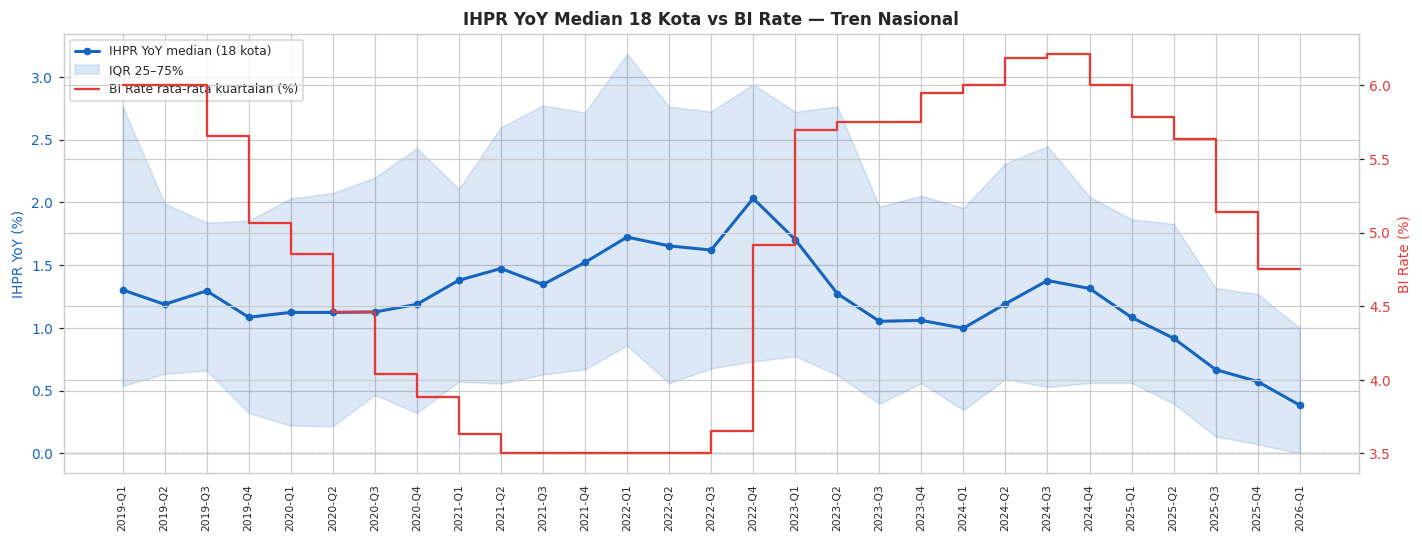

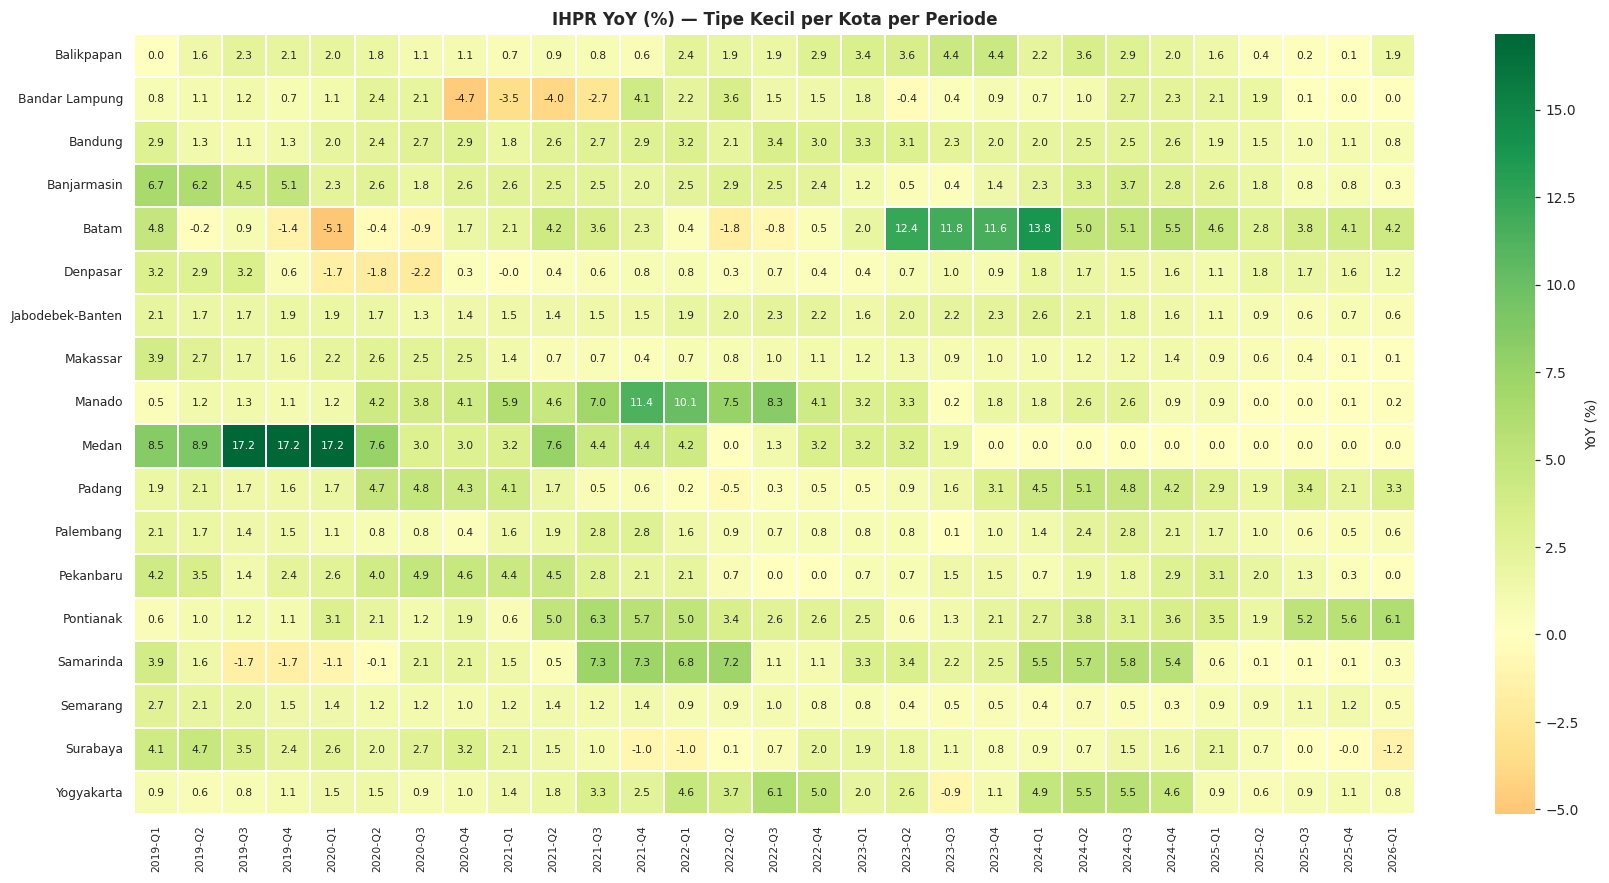

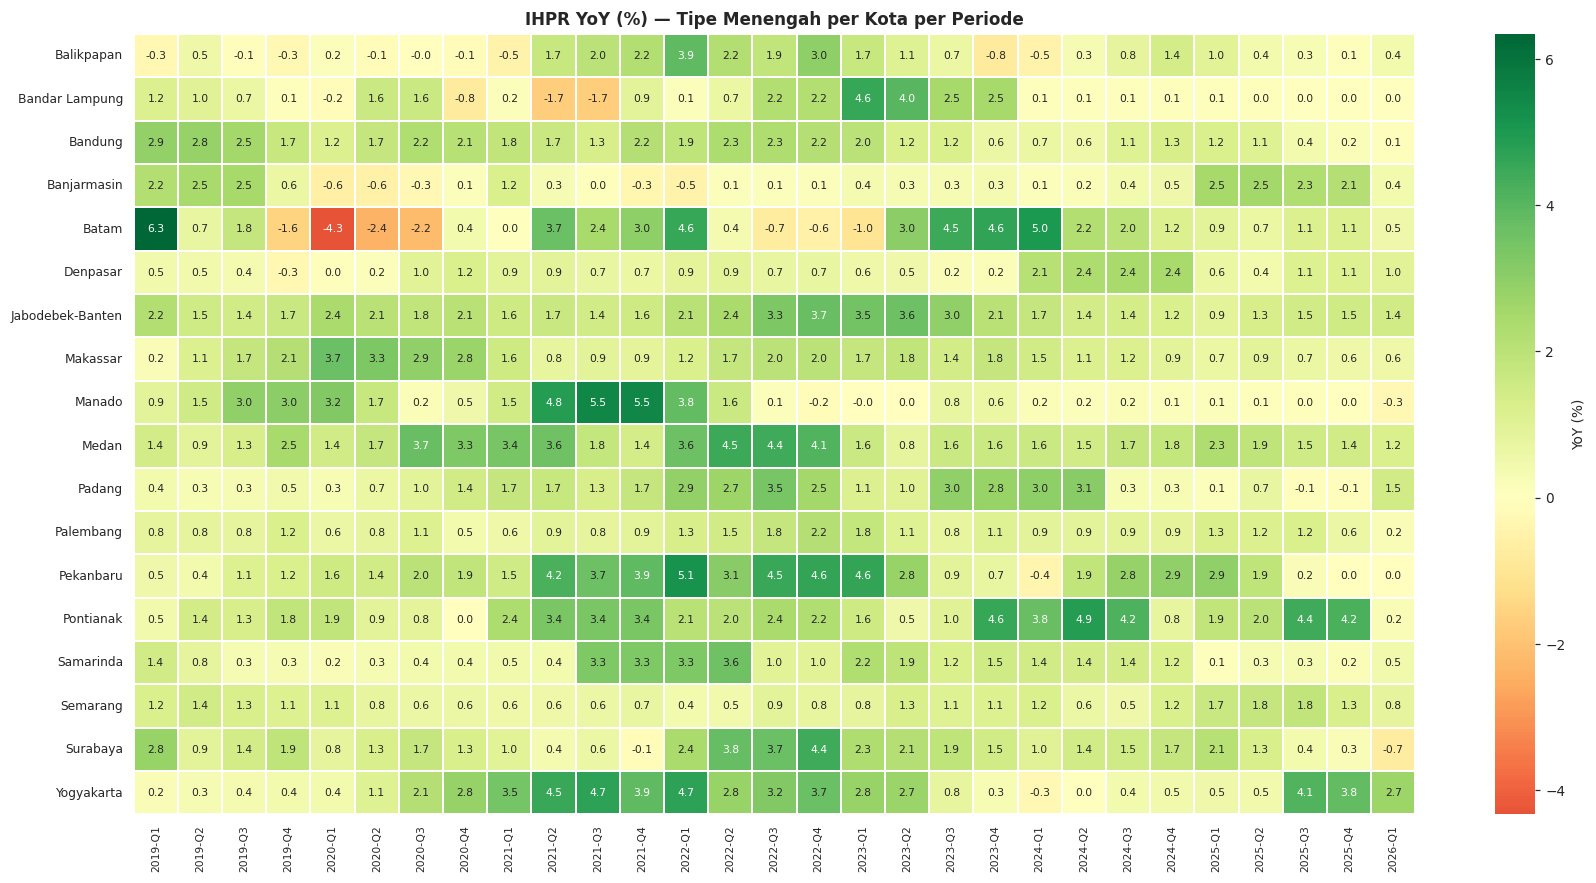

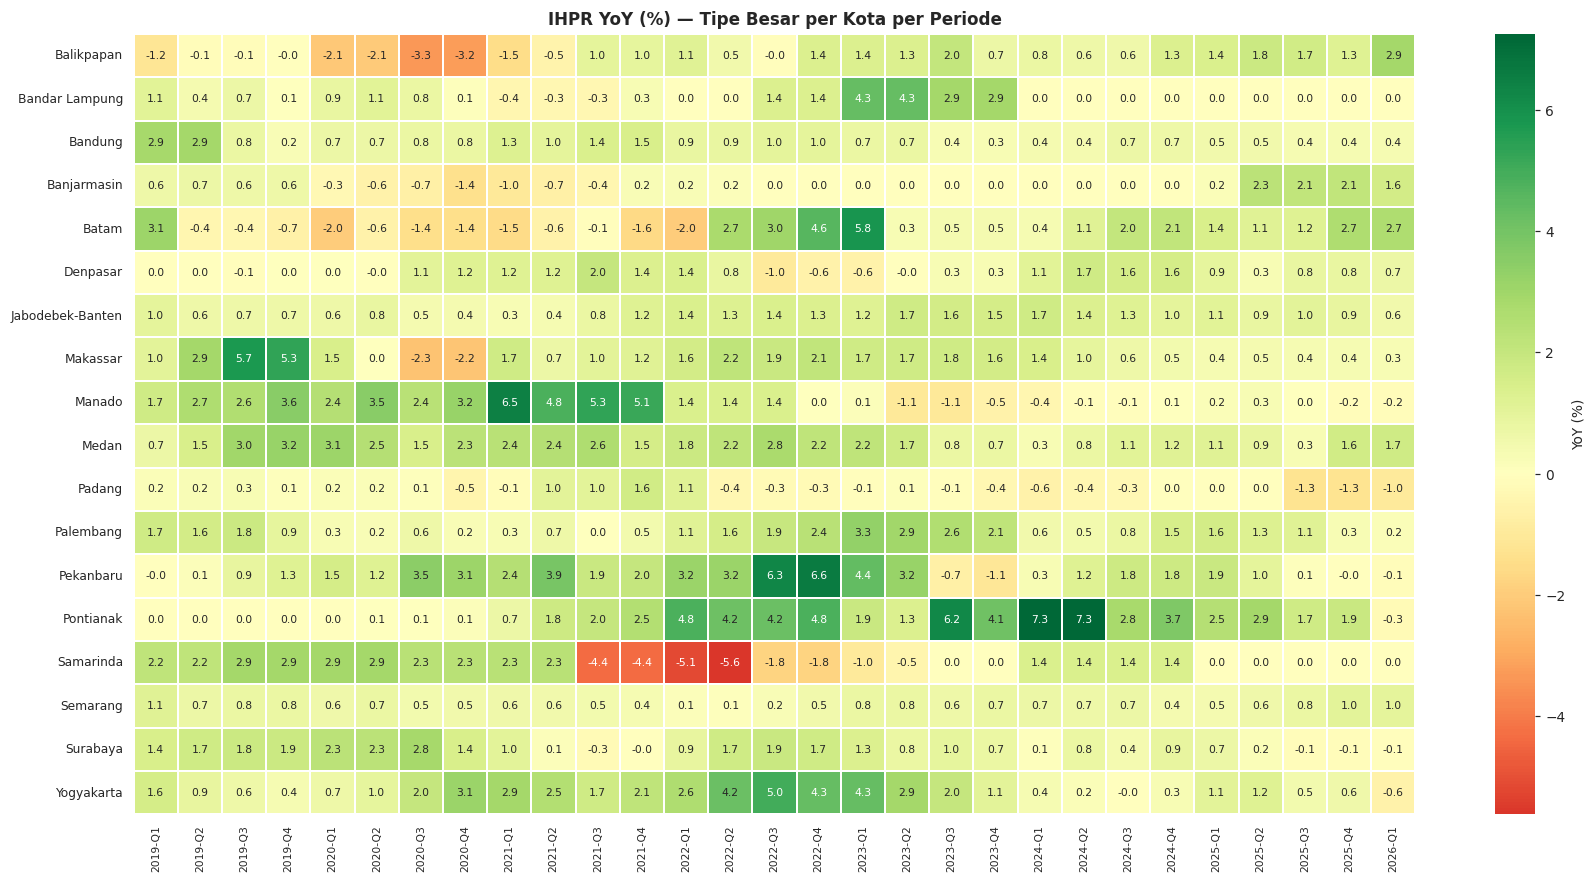

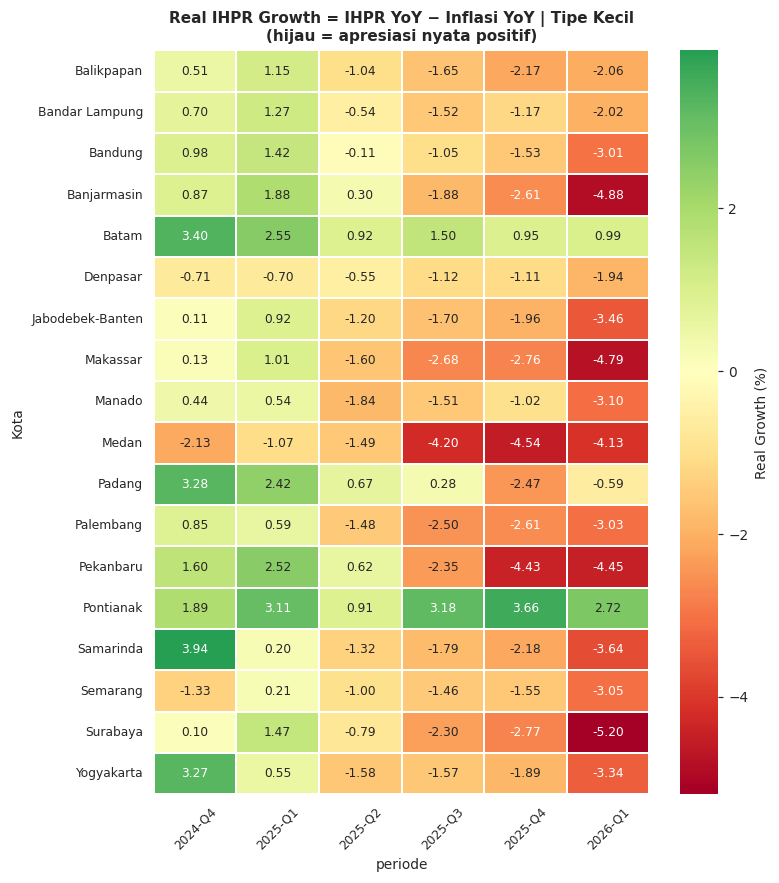

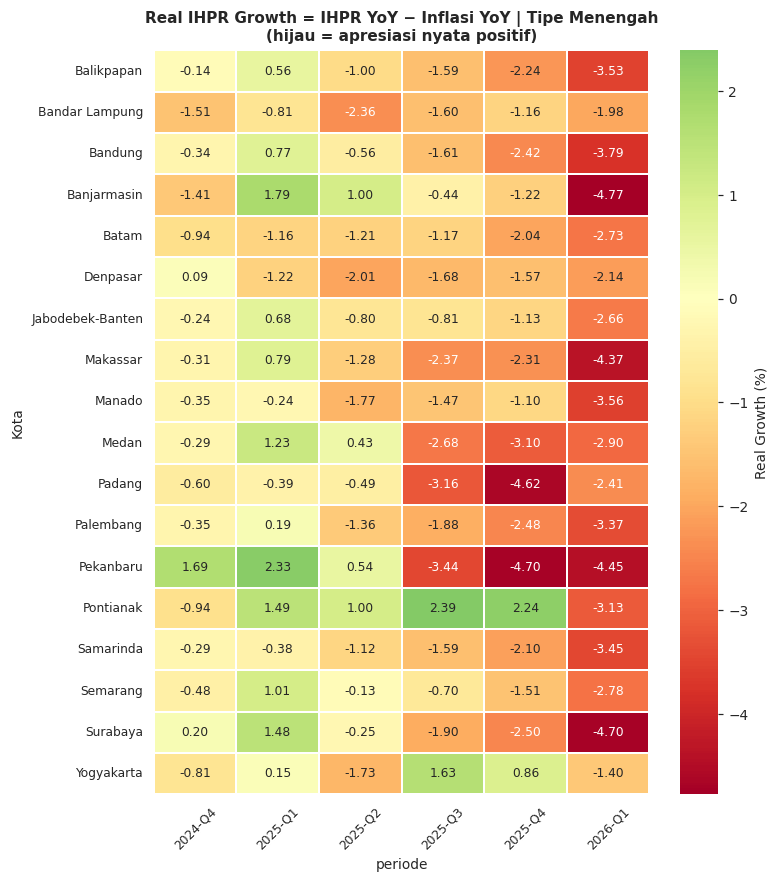

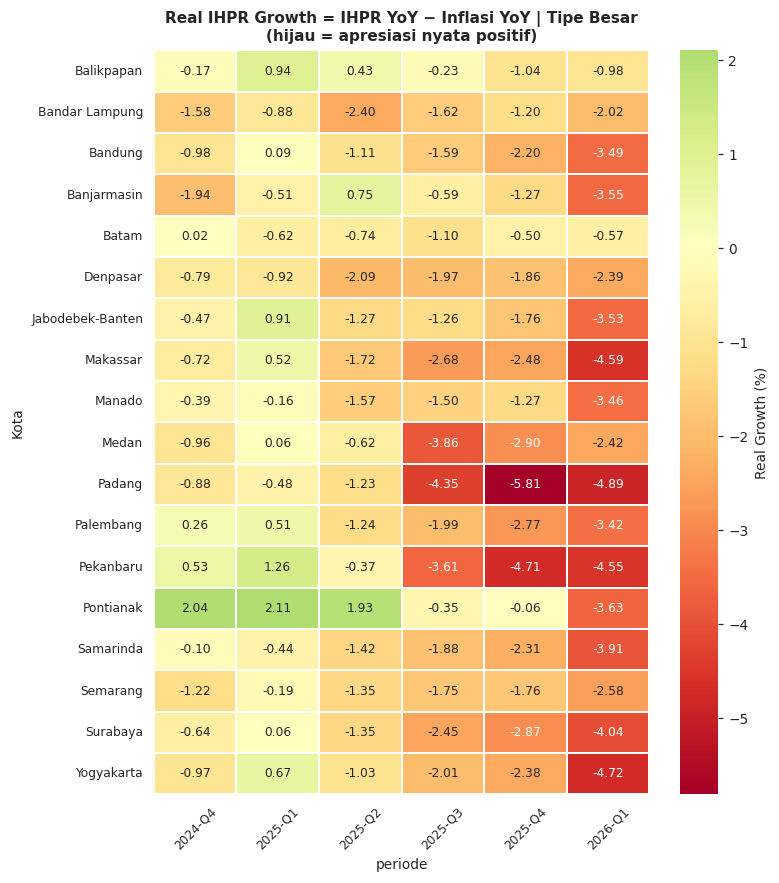

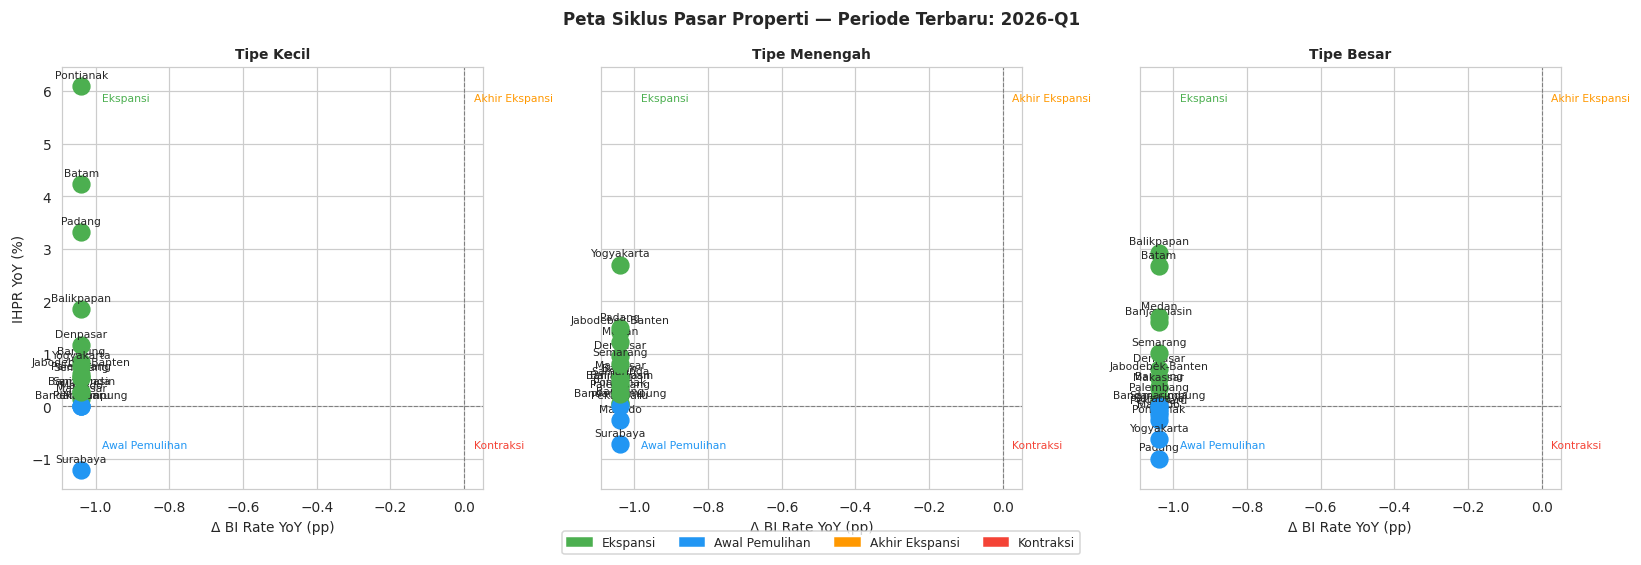

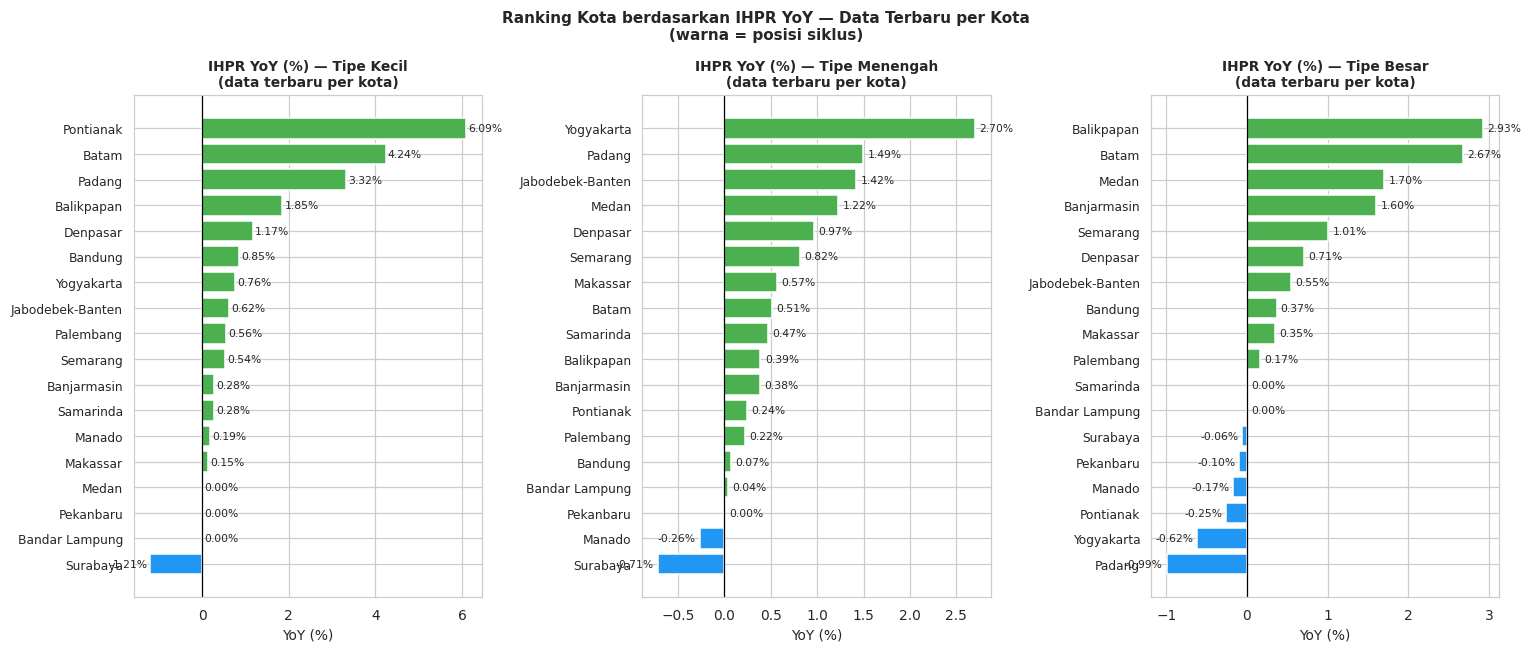

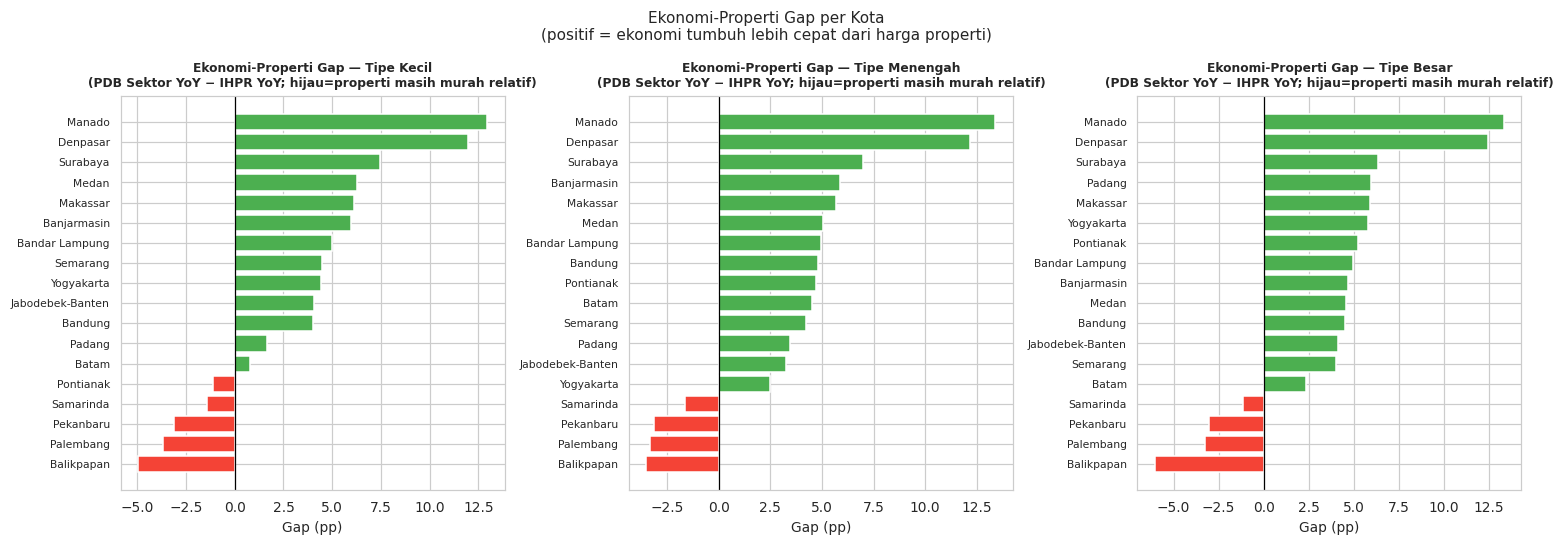

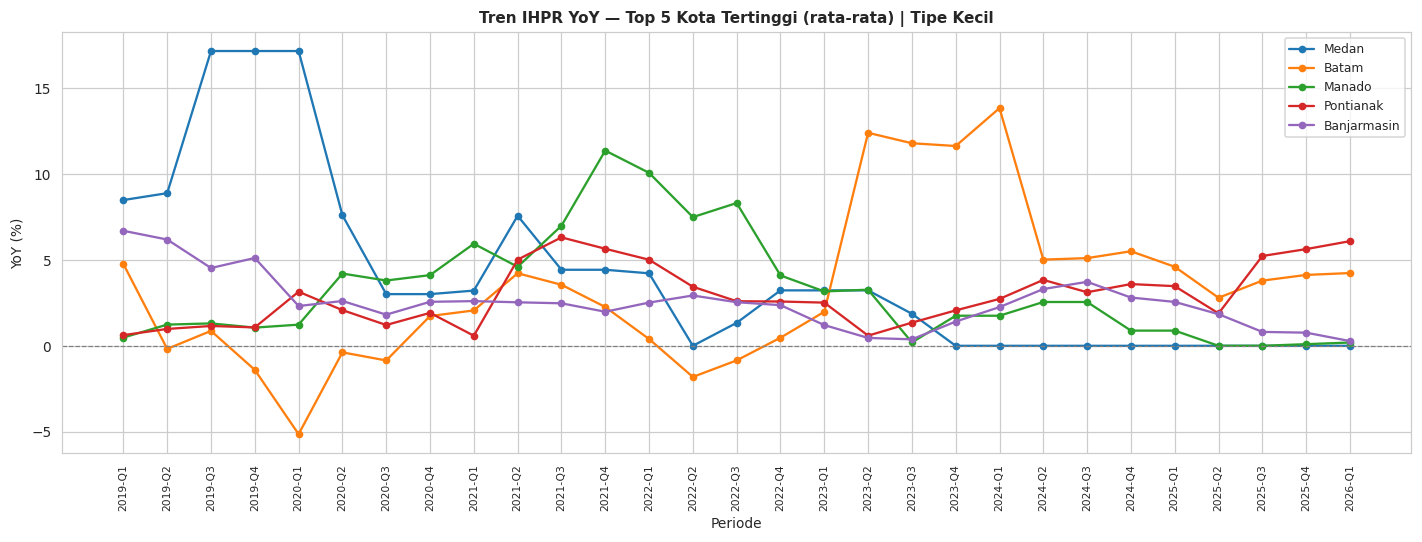

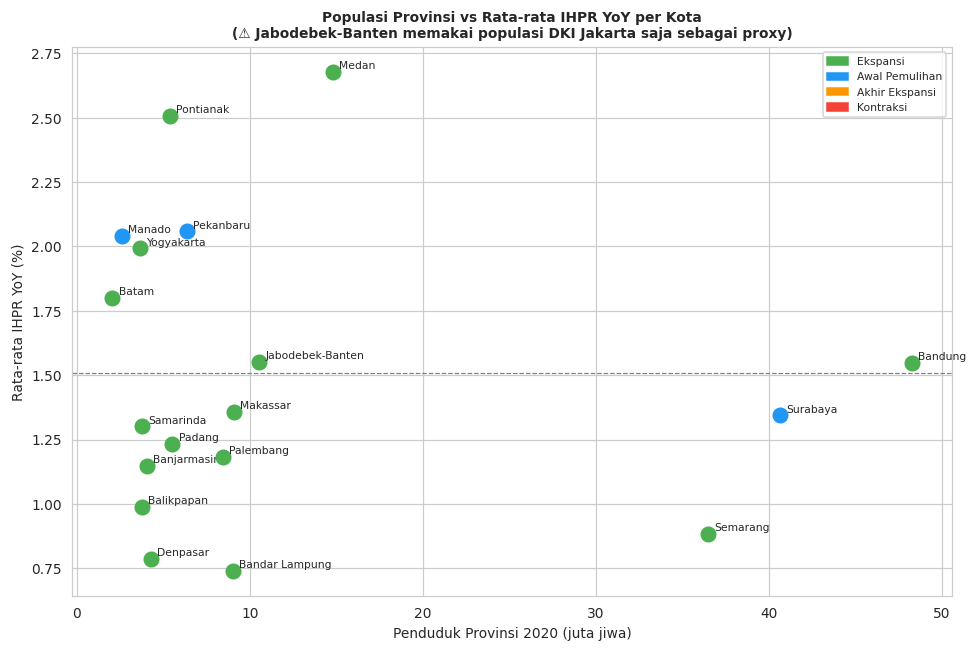


✅ CELL 10 selesai. Semua visualisasi disimpan di /kaggle/working/
 
File yang dihasilkan:
  master_analitik.csv         ← tabel master lengkap siap analisis lanjutan
  viz1_ihpr_vs_birate.png     ← tren IHPR YoY vs BI Rate nasional
  viz2_heatmap_yoy_tipe_*.png ← heatmap IHPR YoY per kota per periode
  viz3_heatmap_realgrowth_*.png ← heatmap real IHPR growth (setelah inflasi)
  viz4_peta_siklus.png        ← peta 4 kuadran siklus pasar
  viz5_ranking_kota.png       ← ranking kota berdasarkan IHPR YoY terbaru
  viz6_ekon_prop_gap.png      ← gap ekonomi vs properti
  viz7_tren_top5_kota.png     ← tren historis top 5 kota
  viz8_populasi_vs_ihpr.png   ← scatter populasi vs rata-rata apresiasi
 
CATATAN PENTING UNTUK INTERPRETASI:
  • Real IHPR growth (Viz 3): hanya reliabel mulai Q4 2024 (inflasi YoY baru
    tersedia Des 2024), paling kuat mulai Q1 2025 (3 bulan lengkap per kuartal)
  • Viz 1,2,4,5,7: bisa menggunakan data IHPR penuh 2018–2026
  • Viz 6: tergantung overlap PDB (2020+) da

In [10]:
TIPE_WARNA = {'Kecil': '#2196F3', 'Menengah': '#FF9800', 'Besar': '#4CAF50'}
SIKLUS_WARNA = {
    'Ekspansi':       '#4CAF50',
    'Awal Pemulihan': '#2196F3',
    'Akhir Ekspansi': '#FF9800',
    'Kontraksi':      '#F44336',
    'Data tidak cukup': '#BDBDBD',
}
 
# ── VIZ 1: IHPR YoY vs BI Rate — tren nasional (gabungan 18 kota) ──────
ihpr_nasional = (
    master.groupby(['Tahun','kuartal_num','periode'])
    .agg(ihpr_yoy_median=('ihpr_yoy','median'),
         ihpr_yoy_q25=('ihpr_yoy',lambda x: x.quantile(.25)),
         ihpr_yoy_q75=('ihpr_yoy',lambda x: x.quantile(.75)),
         bi_rate=('bi_rate_avg','first'))
    .reset_index()
    .sort_values(['Tahun','kuartal_num'])
)
ihpr_nasional = ihpr_nasional[ihpr_nasional['ihpr_yoy_median'].notna()]
 
fig, ax1 = plt.subplots(figsize=(13, 5))
ax2 = ax1.twinx()
# IHPR median + band IQR
ax1.plot(range(len(ihpr_nasional)), ihpr_nasional['ihpr_yoy_median'],
         color='#1565C0', linewidth=2, marker='o', markersize=4, label='IHPR YoY median (18 kota)')
ax1.fill_between(range(len(ihpr_nasional)),
                  ihpr_nasional['ihpr_yoy_q25'], ihpr_nasional['ihpr_yoy_q75'],
                  alpha=0.15, color='#1565C0', label='IQR 25–75%')
ax1.axhline(0, color='gray', linewidth=0.8, linestyle='--')
# BI Rate
ax2.step(range(len(ihpr_nasional)), ihpr_nasional['bi_rate'],
         color='#E53935', linewidth=1.5, where='post', label='BI Rate rata-rata kuartalan (%)')
ax2.set_ylabel('BI Rate (%)', color='#E53935')
ax2.tick_params(axis='y', labelcolor='#E53935')
ax1.set_ylabel('IHPR YoY (%)', color='#1565C0')
ax1.tick_params(axis='y', labelcolor='#1565C0')
ax1.set_xticks(range(len(ihpr_nasional)))
ax1.set_xticklabels(ihpr_nasional['periode'], rotation=90, fontsize=7)
ax1.set_title('IHPR YoY Median 18 Kota vs BI Rate — Tren Nasional', fontsize=11, fontweight='bold')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1+lines2, labels1+labels2, loc='upper left', fontsize=8)
plt.tight_layout()
plt.savefig(f'{KAGGLE_OUTPUT_DIR}/viz1_ihpr_vs_birate.png', bbox_inches='tight')
plt.show(); plt.close()
 
 
# ── VIZ 2: Heatmap IHPR YoY per Kota (semua periode, per Tipe) ─────────
for tipe in ['Kecil','Menengah','Besar']:
    subset = (master[(master['Tipe']==tipe) & master['ihpr_yoy'].notna()]
              .groupby(['Kota','periode'])['ihpr_yoy'].mean()
              .unstack('periode'))
    if subset.empty:
        continue
    # urut kolom kronologis
    cols = sorted(subset.columns, key=lambda p: (int(p.split('-')[0]), int(p.split('-Q')[1])))
    subset = subset[cols]
    fig, ax = plt.subplots(figsize=(max(12, len(cols)*0.55), max(5, len(subset)*0.45)))
    sns.heatmap(subset, ax=ax, cmap='RdYlGn', center=0, annot=True, fmt='.1f',
                annot_kws={'size':7}, linewidths=0.3, cbar_kws={'label':'YoY (%)'})
    ax.set_title(f'IHPR YoY (%) — Tipe {tipe} per Kota per Periode', fontsize=11, fontweight='bold')
    ax.set_xlabel(''); ax.set_ylabel('')
    ax.tick_params(axis='x', rotation=90, labelsize=7)
    ax.tick_params(axis='y', labelsize=8)
    plt.tight_layout()
    plt.savefig(f'{KAGGLE_OUTPUT_DIR}/viz2_heatmap_yoy_tipe_{tipe.lower()}.png', bbox_inches='tight')
    plt.show(); plt.close()
 
 
# ── VIZ 3: Heatmap Real IHPR Growth (IHPR YoY − Inflasi YoY) ──────────
for tipe in ['Kecil','Menengah','Besar']:
    subset = (master[(master['Tipe']==tipe) & master['real_ihpr_growth'].notna()]
              .groupby(['Kota','periode'])['real_ihpr_growth'].mean()
              .unstack('periode'))
    if subset.empty:
        continue
    cols = sorted(subset.columns, key=lambda p: (int(p.split('-')[0]), int(p.split('-Q')[1])))
    subset = subset[cols]
    fig, ax = plt.subplots(figsize=(max(6, len(cols)*1.2), max(5, len(subset)*0.45)))
    sns.heatmap(subset, ax=ax, cmap='RdYlGn', center=0, annot=True, fmt='.2f',
                annot_kws={'size':8}, linewidths=0.3, cbar_kws={'label':'Real Growth (%)'})
    ax.set_title(f'Real IHPR Growth = IHPR YoY − Inflasi YoY | Tipe {tipe}\n'
                 f'(hijau = apresiasi nyata positif)', fontsize=10, fontweight='bold')
    ax.tick_params(axis='x', rotation=45, labelsize=8)
    ax.tick_params(axis='y', labelsize=8)
    plt.tight_layout()
    plt.savefig(f'{KAGGLE_OUTPUT_DIR}/viz3_heatmap_realgrowth_tipe_{tipe.lower()}.png', bbox_inches='tight')
    plt.show(); plt.close()
 
 
# ── VIZ 4: Peta Siklus per Kota — kuartal terbaru ──────────────────────
# BUG FIX: .max() string kebetulan benar untuk format 'YYYY-QN' saat ini
# (tahun 4 digit, kuartal 1 digit -> urutan leksikografis == urutan
# kronologis), tapi itu kebetulan, bukan jaminan. periode_sortkey() (lihat
# CELL awal setup) dipakai konsisten di seluruh notebook untuk urutan
# periode -- di sini disamakan juga.
periode_terbaru = max(
    master[master['posisi_siklus'] != 'Data tidak cukup']['periode'].unique(),
    key=periode_sortkey
)
df_siklus = (master[master['periode'] == periode_terbaru]
             .groupby(['Kota','Tipe'])
             .agg(ihpr_yoy=('ihpr_yoy','mean'),
                  bi_rate_delta=('bi_rate_delta_yoy','first'),
                  posisi=('posisi_siklus','first'))
             .reset_index())
 
if len(df_siklus) > 0:
    fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
    for ax, tipe in zip(axes, ['Kecil','Menengah','Besar']):
        sub = df_siklus[df_siklus['Tipe']==tipe]
        if sub.empty:
            ax.set_visible(False); continue
        for _, row in sub.iterrows():
            warna = SIKLUS_WARNA.get(row['posisi'], '#BDBDBD')
            ax.scatter(row['bi_rate_delta'], row['ihpr_yoy'], color=warna, s=120, zorder=3)
            ax.annotate(row['Kota'], (row['bi_rate_delta'], row['ihpr_yoy']),
                        fontsize=7, ha='center', va='bottom', xytext=(0,4),
                        textcoords='offset points')
        ax.axhline(0, color='gray', linewidth=0.7, linestyle='--')
        ax.axvline(0, color='gray', linewidth=0.7, linestyle='--')
        ax.set_xlabel('Δ BI Rate YoY (pp)')
        ax.set_title(f'Tipe {tipe}', fontsize=9, fontweight='bold')
        # label kuadran
        xlim, ylim = ax.get_xlim(), ax.get_ylim()
        ax.text(xlim[0]*0.9, ylim[1]*0.9, 'Ekspansi', fontsize=7, color='#4CAF50', ha='left')
        ax.text(xlim[1]*0.5, ylim[1]*0.9, 'Akhir Ekspansi', fontsize=7, color='#FF9800')
        ax.text(xlim[0]*0.9, ylim[0]*0.5, 'Awal Pemulihan', fontsize=7, color='#2196F3')
        ax.text(xlim[1]*0.5, ylim[0]*0.5, 'Kontraksi', fontsize=7, color='#F44336')
    axes[0].set_ylabel('IHPR YoY (%)')
    fig.suptitle(f'Peta Siklus Pasar Properti — Periode Terbaru: {periode_terbaru}',
                 fontsize=11, fontweight='bold')
    # legend warna siklus
    from matplotlib.patches import Patch
    legend_els = [Patch(color=c, label=l) for l,c in SIKLUS_WARNA.items() if l != 'Data tidak cukup']
    fig.legend(handles=legend_els, loc='lower center', ncol=4, fontsize=8, bbox_to_anchor=(0.5,-0.02))
    plt.tight_layout()
    plt.savefig(f'{KAGGLE_OUTPUT_DIR}/viz4_peta_siklus.png', bbox_inches='tight')
    plt.show(); plt.close()
 
 
# ── VIZ 5: Ranking kota berdasarkan IHPR YoY — kuartal terbaru ─────────
fig, axes = plt.subplots(1, 3, figsize=(14, 6))
for ax, tipe in zip(axes, ['Kecil','Menengah','Besar']):
    sub = (master[(master['Tipe']==tipe) & master['ihpr_yoy'].notna()]
           .sort_values(['Tahun','kuartal_num'], ascending=False)
           .groupby('Kota')
           .first()
           .reset_index()
           [['Kota','ihpr_yoy','periode','posisi_siklus']]
           .sort_values('ihpr_yoy', ascending=True))
    if sub.empty:
        continue
    colors = [SIKLUS_WARNA.get(p,'#BDBDBD') for p in sub['posisi_siklus']]
    bars = ax.barh(sub['Kota'], sub['ihpr_yoy'], color=colors)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(f'IHPR YoY (%) — Tipe {tipe}\n(data terbaru per kota)', fontsize=9, fontweight='bold')
    ax.set_xlabel('YoY (%)')
    ax.tick_params(axis='y', labelsize=8)
    for bar, val in zip(bars, sub['ihpr_yoy']):
        ax.text(val + (0.05 if val >= 0 else -0.05), bar.get_y() + bar.get_height()/2,
                f'{val:.2f}%', va='center', ha='left' if val >= 0 else 'right', fontsize=7)
plt.suptitle('Ranking Kota berdasarkan IHPR YoY — Data Terbaru per Kota\n'
             '(warna = posisi siklus)', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{KAGGLE_OUTPUT_DIR}/viz5_ranking_kota.png', bbox_inches='tight')
plt.show(); plt.close()
 
 
# ── VIZ 6: Ekonomi-Properti Gap (PDB basis vs IHPR YoY) ────────────────
gap_data = master[master['ekon_prop_gap'].notna()].copy()
if len(gap_data) > 0:
    gap_latest = (gap_data.sort_values(['Tahun','kuartal_num'],ascending=False)
                  .groupby(['Kota','Tipe']).first().reset_index()
                  [['Kota','Tipe','ekon_prop_gap','ihpr_yoy','pdb_basis_yoy','basis_sektor']])
    fig, axes = plt.subplots(1,3,figsize=(14,5),sharey=False)
    for ax, tipe in zip(axes,['Kecil','Menengah','Besar']):
        sub = gap_latest[gap_latest['Tipe']==tipe].sort_values('ekon_prop_gap',ascending=True)
        if sub.empty: continue
        bar_c = ['#4CAF50' if v>0 else '#F44336' for v in sub['ekon_prop_gap']]
        ax.barh(sub['Kota'], sub['ekon_prop_gap'], color=bar_c)
        ax.axvline(0, color='black', linewidth=0.8)
        ax.set_title(f'Ekonomi-Properti Gap — Tipe {tipe}\n'
                     f'(PDB Sektor YoY − IHPR YoY; hijau=properti masih murah relatif)',
                     fontsize=8, fontweight='bold')
        ax.set_xlabel('Gap (pp)')
        ax.tick_params(axis='y', labelsize=7)
    plt.suptitle('Ekonomi-Properti Gap per Kota\n'
                 '(positif = ekonomi tumbuh lebih cepat dari harga properti)', fontsize=10)
    plt.tight_layout()
    plt.savefig(f'{KAGGLE_OUTPUT_DIR}/viz6_ekon_prop_gap.png', bbox_inches='tight')
    plt.show(); plt.close()
else:
    print('ℹ️  VIZ 6 dilewati: ekon_prop_gap belum ada data valid '
          '(PDB dimulai 2020, IHPR YoY dimulai 2019 — perlu overlap yang sama kota+kuartal)')
 
 
# ── VIZ 7: Tren per kota — top 5 tertinggi IHPR YoY (Tipe Kecil) ──────
tipe_plot = 'Kecil'
top5 = (master[(master['Tipe']==tipe_plot) & master['ihpr_yoy'].notna()]
        .groupby('Kota')['ihpr_yoy'].mean()
        .nlargest(5).index.tolist())
plot_data = (master[(master['Kota'].isin(top5)) & (master['Tipe']==tipe_plot)
                     & master['ihpr_yoy'].notna()]
             .sort_values(['Tahun','kuartal_num']))
fig, ax = plt.subplots(figsize=(13,5))
for kota in top5:
    sub = plot_data[plot_data['Kota']==kota]
    ax.plot(sub['periode'], sub['ihpr_yoy'], marker='o', markersize=4,
            linewidth=1.5, label=kota)
ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')
ax.set_title(f'Tren IHPR YoY — Top 5 Kota Tertinggi (rata-rata) | Tipe {tipe_plot}', fontsize=10, fontweight='bold')
ax.set_xlabel('Periode'); ax.set_ylabel('YoY (%)')
ax.tick_params(axis='x', rotation=90, labelsize=7)
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(f'{KAGGLE_OUTPUT_DIR}/viz7_tren_top5_kota.png', bbox_inches='tight')
plt.show(); plt.close()
 
 
# ── VIZ 8: Populasi vs rata-rata IHPR YoY per kota ─────────────────────
pop_ihpr = (master[master['ihpr_yoy'].notna()]
            .groupby(['Kota','Provinsi','penduduk_juta'])
            .agg(ihpr_yoy_mean=('ihpr_yoy','mean'),
                 posisi_terbaru=('posisi_siklus','last'))
            .reset_index()
            .drop_duplicates('Kota'))
if len(pop_ihpr) > 0 and pop_ihpr['penduduk_juta'].notna().sum() > 0:
    fig, ax = plt.subplots(figsize=(9,6))
    for _, row in pop_ihpr.iterrows():
        warna = SIKLUS_WARNA.get(row['posisi_terbaru'],'#BDBDBD')
        ax.scatter(row['penduduk_juta'], row['ihpr_yoy_mean'], color=warna, s=90, zorder=3)
        ax.annotate(row['Kota'], (row['penduduk_juta'], row['ihpr_yoy_mean']),
                    fontsize=7, xytext=(4,2), textcoords='offset points')
    ax.axhline(pop_ihpr['ihpr_yoy_mean'].mean(), color='gray', linestyle='--', linewidth=0.8)
    ax.set_xlabel('Penduduk Provinsi 2020 (juta jiwa)')
    ax.set_ylabel('Rata-rata IHPR YoY (%)')
    ax.set_title('Populasi Provinsi vs Rata-rata IHPR YoY per Kota\n'
                 '(⚠️ Jabodebek-Banten memakai populasi DKI Jakarta saja sebagai proxy)',
                 fontsize=9, fontweight='bold')
    from matplotlib.patches import Patch
    legend_els = [Patch(color=c, label=l) for l,c in SIKLUS_WARNA.items() if l != 'Data tidak cukup']
    ax.legend(handles=legend_els, fontsize=7, loc='upper right')
    plt.tight_layout()
    plt.savefig(f'{KAGGLE_OUTPUT_DIR}/viz8_populasi_vs_ihpr.png', bbox_inches='tight')
    plt.show(); plt.close()
 
print(f"""
✅ CELL 10 selesai. Semua visualisasi disimpan di {KAGGLE_OUTPUT_DIR}/
 
File yang dihasilkan:
  master_analitik.csv         ← tabel master lengkap siap analisis lanjutan
  viz1_ihpr_vs_birate.png     ← tren IHPR YoY vs BI Rate nasional
  viz2_heatmap_yoy_tipe_*.png ← heatmap IHPR YoY per kota per periode
  viz3_heatmap_realgrowth_*.png ← heatmap real IHPR growth (setelah inflasi)
  viz4_peta_siklus.png        ← peta 4 kuadran siklus pasar
  viz5_ranking_kota.png       ← ranking kota berdasarkan IHPR YoY terbaru
  viz6_ekon_prop_gap.png      ← gap ekonomi vs properti
  viz7_tren_top5_kota.png     ← tren historis top 5 kota
  viz8_populasi_vs_ihpr.png   ← scatter populasi vs rata-rata apresiasi
 
CATATAN PENTING UNTUK INTERPRETASI:
  • Real IHPR growth (Viz 3): hanya reliabel mulai Q4 2024 (inflasi YoY baru
    tersedia Des 2024), paling kuat mulai Q1 2025 (3 bulan lengkap per kuartal)
  • Viz 1,2,4,5,7: bisa menggunakan data IHPR penuh 2018–2026
  • Viz 6: tergantung overlap PDB (2020+) dan IHPR YoY (2019+) per kota & sektor
  • Jabodebek-Banten: proxy inflasi = DKI Jakarta, proxy populasi = DKI Jakarta
  • Balikpapan & Samarinda: memakai inflasi Kalimantan Timur yang sama
""")

In [11]:
# ──────────────────────────────────────────────────────────────────────
# CELL 11 — LOAD DATA & AUTO-DETEKSI SEMUA WINDOW WAKTU
# ──────────────────────────────────────────────────────────────────────
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
 
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams.update({'figure.dpi': 110, 'font.size': 9})
 
KAGGLE_OUTPUT_DIR = '/kaggle/working'
 
# Jika 'master' belum ada di memori (mis. notebook baru / restart kernel),
# load langsung dari hasil Stage 2 yang sudah diekspor
if 'master' not in globals():
    print("Variabel 'master' tidak ditemukan di memori — memuat dari CSV Stage 2...")
    master = pd.read_csv(f'{KAGGLE_OUTPUT_DIR}/master_analitik.csv')
    print(f"✅ Dimuat: {len(master)} baris dari master_analitik.csv")
else:
    print(f"✅ Memakai variabel 'master' yang sudah ada di memori ({len(master)} baris)")
 
df = master.copy()
 
def periode_sortkey(p):
    """Urutkan string periode 'YYYY-QN' secara kronologis, bukan alfabetis."""
    y, q = p.split('-Q')
    return (int(y), int(q))
 
n_kota = df['Kota'].nunique()
n_tipe = df['Tipe'].nunique()
max_possible_per_periode = n_kota * n_tipe
print(f"\nJumlah Kota: {n_kota} | Jumlah Tipe: {n_tipe} | Kombinasi Kota×Tipe: {max_possible_per_periode}")
 
 
# ── 11A: Auto-deteksi ANCHOR_QUARTER — kuartal terakhir cakupan PENUH ──
# (dipakai untuk skor posisi siklus "kondisi saat ini")
coverage = df[df['ihpr_yoy'].notna()].groupby('periode').size()
full_periods = coverage[coverage == max_possible_per_periode].index.tolist()
if len(full_periods) == 0:
    raise ValueError("Tidak ada satupun periode dengan cakupan penuh (semua Kota×Tipe). "
                      "Cek apakah data IHPR Anda benar-benar lengkap.")
ANCHOR_QUARTER = sorted(full_periods, key=periode_sortkey)[-1]
 
periode_setelah_anchor = [p for p in df['periode'].unique()
                           if periode_sortkey(p) > periode_sortkey(ANCHOR_QUARTER)]
if periode_setelah_anchor:
    print(f"⚠️  Ditemukan {len(periode_setelah_anchor)} periode SETELAH anchor "
          f"({sorted(periode_setelah_anchor, key=periode_sortkey)}) dengan cakupan TIDAK PENUH.\n"
          f"    Ini bisa berarti data berisi proyeksi/estimasi untuk periode yang belum genap "
          f"berjalan. Periode ini DIABAIKAN untuk skor 'kondisi saat ini' demi adil antar kota.")
print(f"✅ ANCHOR_QUARTER (kondisi 'saat ini' utk skor siklus) = {ANCHOR_QUARTER}")
 
 
# ── 11B: Auto-deteksi RELIABLE_INFLASI_PERIODS via flag yang sudah ada ─
# (dipakai untuk window real_ihpr_growth)
if 'inflasi_yoy_parsial' not in df.columns:
    raise KeyError("Kolom 'inflasi_yoy_parsial' tidak ditemukan — pastikan Stage 2 sudah dijalankan lengkap.")
RELIABLE_INFLASI_PERIODS = sorted(
    df[df['inflasi_yoy_parsial'] == False]['periode'].dropna().unique().tolist(),
    key=periode_sortkey
)
if len(RELIABLE_INFLASI_PERIODS) == 0:
    raise ValueError("Tidak ada periode dengan inflasi YoY yang reliable (non-parsial). "
                      "Real IHPR Growth tidak bisa dihitung dengan data saat ini.")
print(f"✅ RELIABLE_INFLASI_PERIODS ({len(RELIABLE_INFLASI_PERIODS)} kuartal) = {RELIABLE_INFLASI_PERIODS}")
 
 
# ── 11C: Auto-deteksi GAP_WINDOW_YEARS — 3 tahun terakhir dgn data gap ──
years_with_gap = sorted(df[df['ekon_prop_gap'].notna()]['Tahun'].dropna().unique().tolist())
if len(years_with_gap) == 0:
    print("⚠️  Tidak ada data ekon_prop_gap sama sekali — komponen ini akan kosong di skor akhir.")
    GAP_WINDOW_YEARS = []
else:
    GAP_WINDOW_YEARS = years_with_gap[-3:]  # 3 tahun terakhir yang tersedia
print(f"✅ GAP_WINDOW_YEARS (3 tahun terakhir dgn data PDB) = {GAP_WINDOW_YEARS}")
 
 
# ── 11D: Auto-deteksi BASELINE_YEAR & LATEST_YEAR utk momentum ─────────
# Tahun "penuh" = cakupan ihpr_yoy >= 75% dari cakupan tahun terbaik
# (otomatis MENGECUALIKAN tahun berjalan yang baru parsial, mis. tahun ini)
yearly_coverage = df[df['ihpr_yoy'].notna()].groupby('Tahun').size()
threshold = 0.75 * yearly_coverage.max()
full_years = yearly_coverage[yearly_coverage >= threshold].index.tolist()
if len(full_years) < 2:
    raise ValueError(f"Hanya {len(full_years)} tahun dengan cakupan memadai — "
                      f"tidak cukup untuk menghitung arah momentum (butuh minimal 2).")
BASELINE_YEAR, LATEST_YEAR = min(full_years), max(full_years)
tahun_dikecualikan = [y for y in df['Tahun'].unique() if y not in full_years]
if tahun_dikecualikan:
    print(f"ℹ️  Tahun dengan cakupan tidak memadai (dikecualikan dari momentum): {sorted(tahun_dikecualikan)}")
print(f"✅ Momentum dihitung dari BASELINE_YEAR={BASELINE_YEAR} → LATEST_YEAR={LATEST_YEAR}")
 
print("\nCELL 11 selesai. Lanjut ke CELL 12 untuk hitung komponen & skor komposit.")

✅ Memakai variabel 'master' yang sudah ada di memori (1782 baris)

Jumlah Kota: 18 | Jumlah Tipe: 3 | Kombinasi Kota×Tipe: 54
✅ ANCHOR_QUARTER (kondisi 'saat ini' utk skor siklus) = 2026-Q1
✅ RELIABLE_INFLASI_PERIODS (5 kuartal) = ['2025-Q1', '2025-Q2', '2025-Q3', '2025-Q4', '2026-Q1']
✅ GAP_WINDOW_YEARS (3 tahun terakhir dgn data PDB) = [2024, 2025, 2026]
ℹ️  Tahun dengan cakupan tidak memadai (dikecualikan dari momentum): [np.int64(2018), np.int64(2026)]
✅ Momentum dihitung dari BASELINE_YEAR=2019 → LATEST_YEAR=2025

CELL 11 selesai. Lanjut ke CELL 12 untuk hitung komponen & skor komposit.


In [12]:
rg = (df[df['periode'].isin(RELIABLE_INFLASI_PERIODS) & df['real_ihpr_growth'].notna()]
      .groupby(['Kota', 'Tipe'])['real_ihpr_growth']
      .mean()
      .rename('real_growth_avg'))
 
# ── 12B: Komponen 2 — Ekonomi-Properti Gap rata-rata (3 tahun terakhir) ─
if GAP_WINDOW_YEARS:
    gp = (df[df['Tahun'].isin(GAP_WINDOW_YEARS) & df['ekon_prop_gap'].notna()]
          .groupby(['Kota', 'Tipe'])['ekon_prop_gap']
          .mean()
          .rename('ekon_prop_gap_avg'))
else:
    gp = pd.Series(dtype=float, name='ekon_prop_gap_avg')
 
# ── 12C: Komponen 3 — Arah momentum (IHPR YoY rata-rata LATEST - BASELINE) ─
m_base = (df[(df['Tahun'] == BASELINE_YEAR) & df['ihpr_yoy'].notna()]
          .groupby(['Kota', 'Tipe'])['ihpr_yoy'].mean())
m_latest = (df[(df['Tahun'] == LATEST_YEAR) & df['ihpr_yoy'].notna()]
            .groupby(['Kota', 'Tipe'])['ihpr_yoy'].mean())
momentum = (m_latest - m_base).rename('momentum_delta')
 
# ── 12D: Komponen 4 — Posisi siklus di ANCHOR_QUARTER ──────────────────
# Ordinal: Awal Pemulihan = entry terbaik (BI turun, harga belum naik = upside terbesar)
#          Ekspansi       = momentum sudah jalan (BI turun, harga sudah naik)
#          Akhir Ekspansi = hati-hati (BI naik, harga masih naik = potensi reversal)
#          Kontraksi      = hindari (BI naik, harga turun)
SIKLUS_SCORE_MAP = {'Awal Pemulihan': 100, 'Ekspansi': 70, 'Akhir Ekspansi': 30, 'Kontraksi': 0}
snap = df[df['periode'] == ANCHOR_QUARTER].copy()
snap['siklus_score_raw'] = snap['posisi_siklus'].map(SIKLUS_SCORE_MAP)
n_unmapped = snap['siklus_score_raw'].isna().sum() - (snap['posisi_siklus']=='Data tidak cukup').sum()
if n_unmapped > 0:
    print(f"⚠️  {n_unmapped} baris punya nilai posisi_siklus yang tidak dikenali SIKLUS_SCORE_MAP — cek isinya.")
siklus = snap.set_index(['Kota', 'Tipe'])['siklus_score_raw'].rename('siklus_score_raw')
 
# ── 12E: Gabungkan semua komponen ───────────────────────────────────────
raw = pd.concat([rg, gp, momentum, siklus], axis=1)
 
# tambahkan konteks (tidak ikut dihitung ke skor, hanya referensi)
konteks_cols = ['Provinsi', 'penduduk_juta', 'basis_sektor']
konteks_cols = [c for c in konteks_cols if c in df.columns]
konteks = df[['Kota'] + konteks_cols].drop_duplicates('Kota').set_index('Kota')
raw = raw.join(konteks, on='Kota')
 
n_lengkap = raw[['real_growth_avg', 'momentum_delta', 'siklus_score_raw']].dropna().shape[0]
print(f"Kombinasi Kota×Tipe dengan data lengkap (3 komponen wajib): {n_lengkap} dari {len(raw)}")
if 'ekon_prop_gap_avg' in raw.columns:
    n_dgn_gap = raw['ekon_prop_gap_avg'].notna().sum()
    print(f"  + dengan ekon_prop_gap_avg juga lengkap: {n_dgn_gap} dari {len(raw)}")
 
 
# ── 12F: Normalisasi min-max ke skala 0-100 (relatif antar semua kombinasi) ─
def minmax_100(s):
    rng = s.max() - s.min()
    if rng == 0 or pd.isna(rng):
        return pd.Series(50.0, index=s.index)  # semua sama -> netral di tengah, hindari div/0
    return (s - s.min()) / rng * 100
 
raw['score_real_growth'] = minmax_100(raw['real_growth_avg'])
raw['score_ekon_gap']    = minmax_100(raw['ekon_prop_gap_avg']) if 'ekon_prop_gap_avg' in raw.columns else np.nan
raw['score_momentum']    = minmax_100(raw['momentum_delta'])
# siklus TIDAK di-minmax -- skala absolut dipertahankan (70=Ekspansi harus selalu
# berarti sama, tidak relatif terhadap kombinasi kota+tipe lain)
raw['score_siklus']      = raw['siklus_score_raw']
 
 
# ── 12G: Skema bobot — 5 perspektif investor berbeda ───────────────────
SKEMA_BOBOT = {
    'A_Utama':          {'real_growth': .35, 'ekon_gap': .25, 'momentum': .25, 'siklus': .15},
    'B_SamaRata':       {'real_growth': .25, 'ekon_gap': .25, 'momentum': .25, 'siklus': .25},
    'C_FokusValue':     {'real_growth': .20, 'ekon_gap': .45, 'momentum': .20, 'siklus': .15},
    'D_FokusMomentum':  {'real_growth': .20, 'ekon_gap': .15, 'momentum': .50, 'siklus': .15},
    'E_FokusReturnRiil':{'real_growth': .60, 'ekon_gap': .15, 'momentum': .15, 'siklus': .10},
}
for nama, w in SKEMA_BOBOT.items():
    assert abs(sum(w.values()) - 1.0) < 1e-9, f"Bobot skema {nama} tidak berjumlah 100%"
 
def hitung_skor(raw, w):
    return (raw['score_real_growth'].fillna(0) * w['real_growth'] +
            raw['score_ekon_gap'].fillna(0)    * w['ekon_gap'] +
            raw['score_momentum'].fillna(0)    * w['momentum'] +
            raw['score_siklus'].fillna(0)      * w['siklus'])
 
for nama, w in SKEMA_BOBOT.items():
    raw[f'skor_{nama}'] = hitung_skor(raw, w)
 
# skor utama yang dipakai sbg rujukan default
raw['SKOR_KOMPOSIT'] = raw['skor_A_Utama']
 
# ── 12H: Ranking & sensitivitas lintas skema ───────────────────────────
rank_cols = [f'skor_{nama}' for nama in SKEMA_BOBOT]
for nama in SKEMA_BOBOT:
    raw[f'rank_{nama}'] = raw[f'skor_{nama}'].rank(ascending=False, method='min').astype('Int64')
 
raw['rank_rata2'] = raw[[f'rank_{n}' for n in SKEMA_BOBOT]].mean(axis=1).round(1)
raw['rank_std'] = raw[[f'rank_{n}' for n in SKEMA_BOBOT]].std(axis=1).round(1)
 
hasil = raw.sort_values('SKOR_KOMPOSIT', ascending=False).reset_index()
hasil['Rank_Utama'] = range(1, len(hasil) + 1)
 
print(f"\n{'='*100}")
print(f"TOP 10 KOMBINASI KOTA × TIPE — Skema Utama (bobot 35/25/25/15)")
print(f"{'='*100}")
kolom_tampil = ['Rank_Utama','Kota','Tipe','SKOR_KOMPOSIT','rank_rata2','rank_std',
                 'score_real_growth','score_ekon_gap','score_momentum','score_siklus']
print(hasil[kolom_tampil].head(10).to_string(index=False))
 
print(f"\n{'='*100}")
print(f"BOTTOM 5 KOMBINASI KOTA × TIPE — Skema Utama")
print(f"{'='*100}")
print(hasil[kolom_tampil].tail(5).to_string(index=False))
 
# ── Validasi otomatis ───────────────────────────────────────────────────
assert hasil['SKOR_KOMPOSIT'].iloc[0] == hasil['SKOR_KOMPOSIT'].max(), "Urutan ranking salah"
assert hasil['Rank_Utama'].nunique() == len(hasil), "Ada duplikasi ranking"
print(f"\n✅ Validasi lulus: {len(hasil)} kombinasi Kota×Tipe berhasil di-ranking tanpa duplikasi")
 
hasil.to_csv(f'{KAGGLE_OUTPUT_DIR}/skor_komposit_kota_tipe.csv', index=False)
print(f"✅ Tersimpan: skor_komposit_kota_tipe.csv")
print("\nCELL 12 selesai. Lanjut ke CELL 13 untuk visualisasi.")

Kombinasi Kota×Tipe dengan data lengkap (3 komponen wajib): 54 dari 54
  + dengan ekon_prop_gap_avg juga lengkap: 54 dari 54

TOP 10 KOMBINASI KOTA × TIPE — Skema Utama (bobot 35/25/25/15)
 Rank_Utama       Kota     Tipe  SKOR_KOMPOSIT  rank_rata2  rank_std  score_real_growth  score_ekon_gap  score_momentum  score_siklus
          1  Pontianak    Kecil      73.227182         6.2      10.5         100.000000       10.908729      100.000000            70
          2     Manado Menengah      66.686270         5.8       6.2          28.483045       99.013796       67.855021           100
          3     Manado    Besar      66.379639         7.2       6.8          29.046468      100.000000       64.853501           100
          4      Batam    Kecil      65.402169        11.6      14.9          78.046256       12.091124       98.252795            70
          5 Yogyakarta Menengah      64.547858         6.6       3.2          53.688868       48.352925       92.674091            70
       

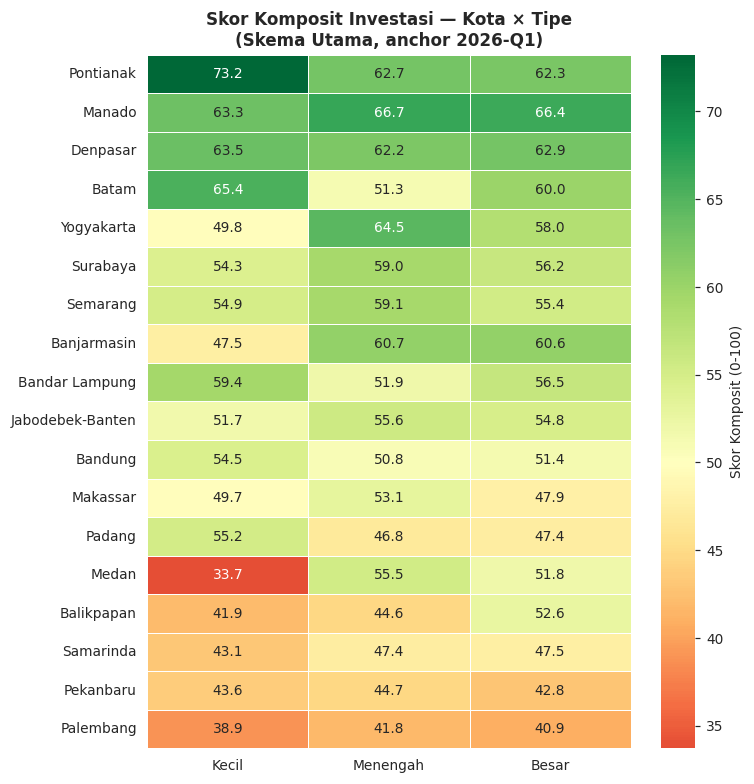

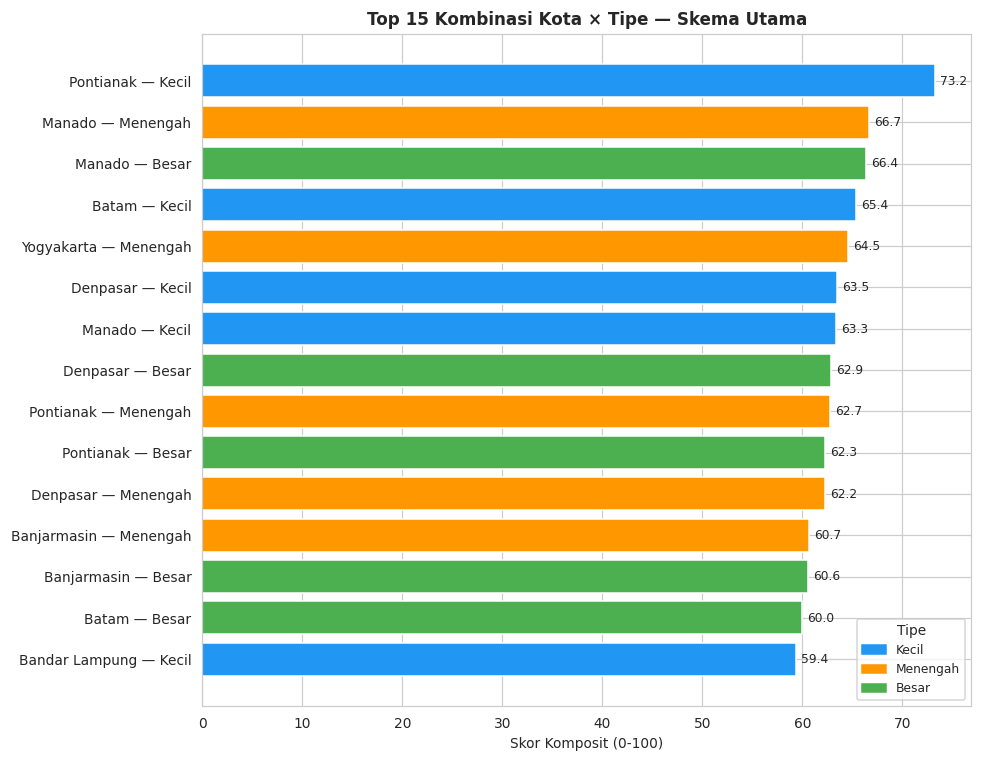

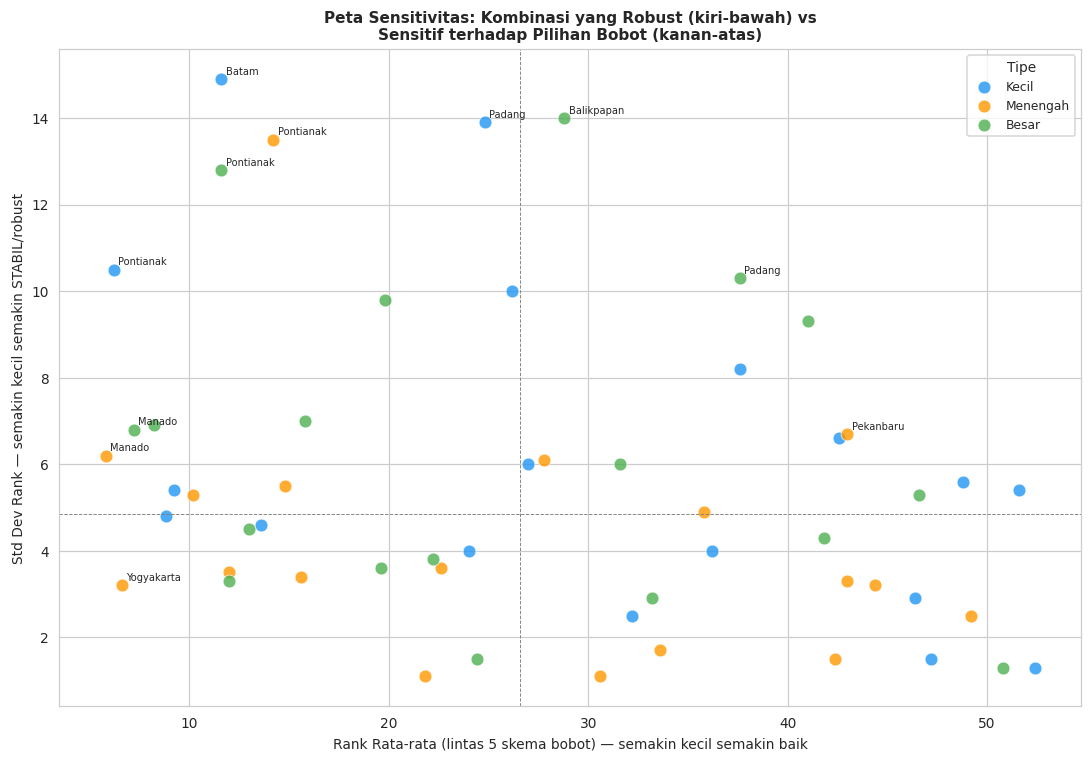

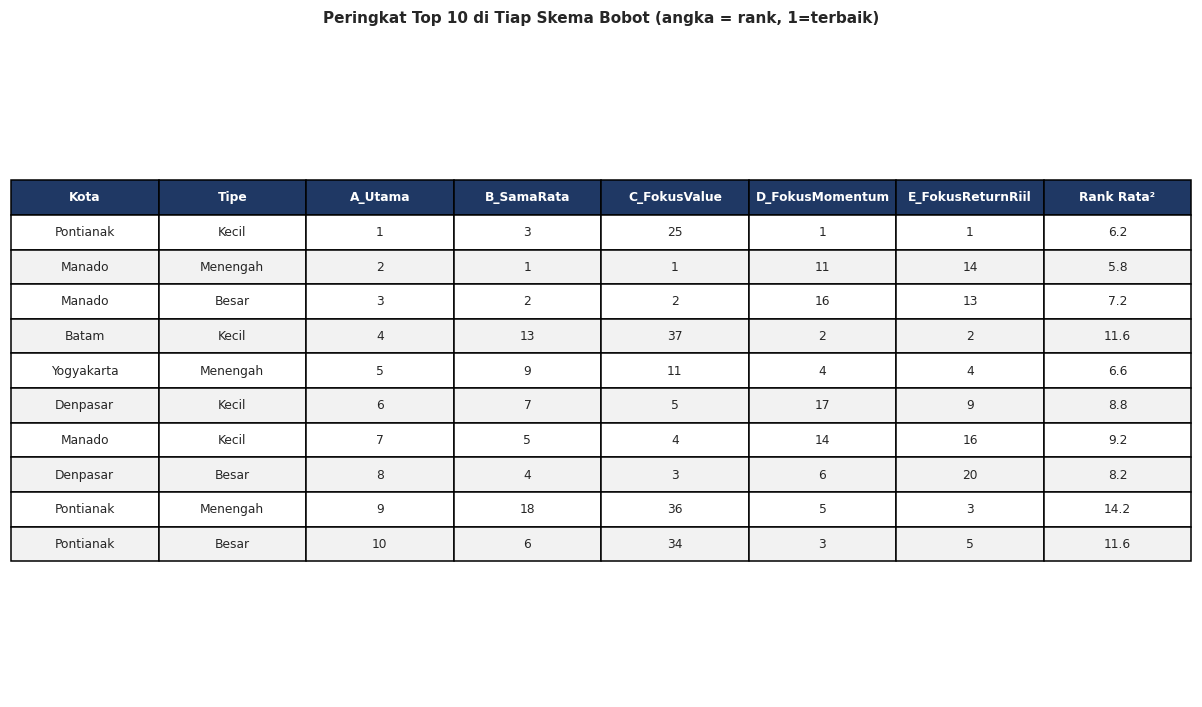


✅ CELL 13 selesai. Semua output tersimpan di /kaggle/working/
 
File yang dihasilkan:
  skor_komposit_kota_tipe.csv  ← tabel lengkap semua kombinasi + 5 skema skor + rank
  vizA_heatmap_skor_kota_tipe.png  ← heatmap skor per Kota × Tipe
  vizB_top15_ranking.png            ← ranking horizontal top 15
  vizC_sensitivitas_bobot.png       ← peta robust vs sensitif terhadap bobot
  vizD_tabel_sensitivitas.png       ← tabel rank top 10 di tiap skema
 
CARA BACA vizC (paling penting utk keputusan):
  - Titik di kiri-BAWAH = skor tinggi DAN stabil di semua skema bobot
    → sinyal paling bisa dipercaya
  - Titik di kiri-ATAS = skor tinggi tapi BERUBAH-UBAH tergantung skema
    → cek dulu skema mana yg paling sesuai prioritas Anda sebelum percaya
  - Titik di kanan (rank rata² besar) = secara umum kurang kompetitif
    di semua skema bobot manapun
 
CATATAN: window waktu (anchor=2026-Q1, baseline=2019,
latest=2025) terdeteksi OTOMATIS dari data Anda saat ini. Kalau
Anda re-run notebook ini nan

In [13]:
TIPE_ORDER = ['Kecil', 'Menengah', 'Besar']
TIPE_WARNA = {'Kecil': '#2196F3', 'Menengah': '#FF9800', 'Besar': '#4CAF50'}
 
# ── VIZ A: Heatmap Skor Komposit — Kota (baris) × Tipe (kolom) ─────────
pivot_skor = hasil.pivot_table(index='Kota', columns='Tipe', values='SKOR_KOMPOSIT')
pivot_skor = pivot_skor[[t for t in TIPE_ORDER if t in pivot_skor.columns]]
pivot_skor = pivot_skor.loc[pivot_skor.mean(axis=1).sort_values(ascending=False).index]
 
fig, ax = plt.subplots(figsize=(7, max(5, len(pivot_skor)*0.4)))
sns.heatmap(pivot_skor, annot=True, fmt='.1f', cmap='RdYlGn', center=50,
            linewidths=0.4, cbar_kws={'label':'Skor Komposit (0-100)'}, ax=ax)
ax.set_title(f'Skor Komposit Investasi — Kota × Tipe\n(Skema Utama, anchor {ANCHOR_QUARTER})',
             fontsize=11, fontweight='bold')
ax.set_xlabel(''); ax.set_ylabel('')
plt.tight_layout()
plt.savefig(f'{KAGGLE_OUTPUT_DIR}/vizA_heatmap_skor_kota_tipe.png', bbox_inches='tight')
plt.show(); plt.close()
 
 
# ── VIZ B: Ranking horizontal — Top 15 kombinasi terbaik ───────────────
top15 = hasil.head(15).copy()
top15['label'] = top15['Kota'] + ' — ' + top15['Tipe']
fig, ax = plt.subplots(figsize=(9, 7))
colors = [TIPE_WARNA.get(t, '#999') for t in top15['Tipe']]
bars = ax.barh(top15['label'][::-1], top15['SKOR_KOMPOSIT'][::-1], color=colors[::-1])
ax.set_xlabel('Skor Komposit (0-100)')
ax.set_title(f'Top 15 Kombinasi Kota × Tipe — Skema Utama', fontsize=11, fontweight='bold')
for bar, val in zip(bars, top15['SKOR_KOMPOSIT'][::-1]):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2, f'{val:.1f}', va='center', fontsize=8)
from matplotlib.patches import Patch
legend_els = [Patch(color=c, label=t) for t, c in TIPE_WARNA.items()]
ax.legend(handles=legend_els, loc='lower right', fontsize=8, title='Tipe')
plt.tight_layout()
plt.savefig(f'{KAGGLE_OUTPUT_DIR}/vizB_top15_ranking.png', bbox_inches='tight')
plt.show(); plt.close()
 
 
# ── VIZ C: Sensitivitas — rank rata² vs std lintas 5 skema bobot ───────
fig, ax = plt.subplots(figsize=(10, 7))
for tipe in TIPE_ORDER:
    sub = hasil[hasil['Tipe'] == tipe]
    if sub.empty:
        continue
    ax.scatter(sub['rank_rata2'], sub['rank_std'], color=TIPE_WARNA.get(tipe,'#999'),
               s=70, label=tipe, alpha=0.8, edgecolors='white', linewidth=0.5)
    for _, row in sub.iterrows():
        if row['rank_rata2'] <= 8 or row['rank_std'] >= sub['rank_std'].quantile(0.85):
            ax.annotate(f"{row['Kota']}", (row['rank_rata2'], row['rank_std']),
                        fontsize=6.5, xytext=(3,3), textcoords='offset points')
ax.set_xlabel('Rank Rata-rata (lintas 5 skema bobot) — semakin kecil semakin baik')
ax.set_ylabel('Std Dev Rank — semakin kecil semakin STABIL/robust')
ax.set_title('Peta Sensitivitas: Kombinasi yang Robust (kiri-bawah) vs\nSensitif terhadap Pilihan Bobot (kanan-atas)',
             fontsize=10, fontweight='bold')
ax.legend(title='Tipe', fontsize=8)
ax.axvline(hasil['rank_rata2'].median(), color='gray', linestyle='--', linewidth=0.6)
ax.axhline(hasil['rank_std'].median(), color='gray', linestyle='--', linewidth=0.6)
plt.tight_layout()
plt.savefig(f'{KAGGLE_OUTPUT_DIR}/vizC_sensitivitas_bobot.png', bbox_inches='tight')
plt.show(); plt.close()
 
 
# ── VIZ D: Tabel sensitivitas Top 10 per skema (gambar tabel, bukan chart) ─
top10_utama = hasil.head(10)['Kota'].tolist()
top10_tipe = hasil.head(10)['Tipe'].tolist()
tabel_data = []
header = ['Kota','Tipe'] + list(SKEMA_BOBOT.keys()) + ['Rank Rata²']
for kota, tipe in zip(top10_utama, top10_tipe):
    row_data = hasil[(hasil['Kota']==kota)&(hasil['Tipe']==tipe)].iloc[0]
    tabel_data.append([kota, tipe] + [int(row_data[f'rank_{n}']) for n in SKEMA_BOBOT] + [f"{row_data['rank_rata2']:.1f}"])
 
fig, ax = plt.subplots(figsize=(11, 0.5*len(tabel_data)+1.5))
ax.axis('off')
tbl = ax.table(cellText=tabel_data, colLabels=header, loc='center', cellLoc='center')
tbl.auto_set_font_size(False); tbl.set_fontsize(8); tbl.scale(1, 1.6)
for j in range(len(header)):
    tbl[0, j].set_facecolor('#1F3864'); tbl[0, j].set_text_props(color='white', fontweight='bold')
for i in range(1, len(tabel_data)+1):
    for j in range(len(header)):
        tbl[i, j].set_facecolor('#F2F2F2' if i % 2 == 0 else 'white')
ax.set_title('Peringkat Top 10 di Tiap Skema Bobot (angka = rank, 1=terbaik)',
              fontsize=10, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig(f'{KAGGLE_OUTPUT_DIR}/vizD_tabel_sensitivitas.png', bbox_inches='tight')
plt.show(); plt.close()
 
print(f"""
✅ CELL 13 selesai. Semua output tersimpan di {KAGGLE_OUTPUT_DIR}/
 
File yang dihasilkan:
  skor_komposit_kota_tipe.csv  ← tabel lengkap semua kombinasi + 5 skema skor + rank
  vizA_heatmap_skor_kota_tipe.png  ← heatmap skor per Kota × Tipe
  vizB_top15_ranking.png            ← ranking horizontal top 15
  vizC_sensitivitas_bobot.png       ← peta robust vs sensitif terhadap bobot
  vizD_tabel_sensitivitas.png       ← tabel rank top 10 di tiap skema
 
CARA BACA vizC (paling penting utk keputusan):
  - Titik di kiri-BAWAH = skor tinggi DAN stabil di semua skema bobot
    → sinyal paling bisa dipercaya
  - Titik di kiri-ATAS = skor tinggi tapi BERUBAH-UBAH tergantung skema
    → cek dulu skema mana yg paling sesuai prioritas Anda sebelum percaya
  - Titik di kanan (rank rata² besar) = secara umum kurang kompetitif
    di semua skema bobot manapun
 
CATATAN: window waktu (anchor={ANCHOR_QUARTER}, baseline={BASELINE_YEAR},
latest={LATEST_YEAR}) terdeteksi OTOMATIS dari data Anda saat ini. Kalau
Anda re-run notebook ini nanti setelah data bertambah, angka-angka window
ini akan ikut bergeser otomatis mengikuti data terbaru — bukan tertanam
permanen di kode.
""")

In [14]:
# ──────────────────────────────────────────────────────────────────────
# CELL 14 — LOAD, BERSIHKAN, & DIAGNOSIS DATA LISTING
# ──────────────────────────────────────────────────────────────────────
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
 
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams.update({'figure.dpi': 110, 'font.size': 9})
 
KAGGLE_OUTPUT_DIR = '/kaggle/working'
KAGGLE_INPUT_DIR  = '/kaggle/input'
 
def find_file(keyword, base_dir=KAGGLE_INPUT_DIR):
    matches = []
    for root, _, files in os.walk(base_dir):
        for f in files:
            if keyword.lower() in f.lower():
                matches.append(os.path.join(root, f))
    if not matches:
        raise FileNotFoundError(f"Tidak ada file mengandung '{keyword}' di {base_dir}.")
    if len(matches) > 1:
        print(f"⚠️  {len(matches)} file cocok utk '{keyword}', memakai: {matches[0]}")
    return matches[0]
 
path_listing = find_file('rumah_bandung')
print(f"Membaca: {path_listing}")
df_raw = pd.read_csv(path_listing)
print(f"✅ Dimuat: {len(df_raw)} baris, {df_raw.shape[1]} kolom")
 
 
# ── 14A: Buang baris tanpa info lokasi ──────────────────────────────────
n_before = len(df_raw)
# BUG FIX: sebelumnya hanya 'city' yang dicek notna(), padahal pesan di
# bawah menyebut "city/area", dan CELL 15 nanti groupby('area') akan diam-
# diam MEMBUANG baris dengan area kosong (groupby default dropna=True,
# bukan error) -- baru ketahuan lewat assert total listing di CELL 15 kalau
# sampai totalnya tidak cocok. Saat ini city & area kebetulan selalu kosong
# bersamaan (assert-nya lolos), tapi filter di bawah ini dibuat eksplisit
# cek keduanya supaya tidak bergantung pada kebetulan itu.
df = df_raw[df_raw['city'].notna() & df_raw['area'].notna()].copy()
n_dropped = n_before - len(df)
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])
print(f"✅ Dibuang {n_dropped} baris tanpa city/area → tersisa {len(df)} baris")
 
 
# ── 14B: Bersihkan Land & Building ──────────────────────────────────────
df['Land_clean'] = pd.to_numeric(
    df['Land'].astype(str).str.replace(',', '', regex=False), errors='coerce')
df['Building_clean'] = pd.to_numeric(
    df['Building'].astype(str).str.replace(',', '', regex=False), errors='coerce')
n_fail = df[['Land_clean','Building_clean']].isna().any(axis=1).sum()
print(f"{'✅' if n_fail==0 else '⚠️ '} Land & Building: {n_fail} baris gagal parse")

# ── 14B.1: Buang baris dengan deskripsi, luas tanah, atau luas bangunan kosong ──
n_before = len(df)

mask_valid = (
    df['Description'].notna() &
    (df['Description'].astype(str).str.strip() != '') &
    df['Land_clean'].notna() &
    df['Building_clean'].notna()
)

df = df[mask_valid].copy()

n_dropped = n_before - len(df)
print(f"✅ Dibuang {n_dropped} baris karena Description/Land/Building kosong")
print(f"✅ Tersisa {len(df)} baris")
 
 
# ── 14C: Parser score_price & rec_score — dua format berbeda ────────────
# Format 1 (corrupted decimal, 99.94%): '4.367.851...' → rekonstruksi ke 0.4367...
# Format 2 (scientific notation, 0.05%): '9,28E+09' → flagged NaN (bukan skor 0-1)
# Format 3 (literal, 0.005%): '1.0' → pakai apa adanya jika dalam range 0-1
def parse_skor_kolom(series):
    hasil, flags = [], []
    for val in series:
        if pd.isna(val):
            hasil.append(np.nan); flags.append('kosong'); continue
        v = str(val).strip()
        if 'E' in v or 'e' in v:
            # scientific notation — nilai ini bukan skor 0-1, tandai sebagai NaN
            hasil.append(np.nan); flags.append('scientific_bukan_skor'); continue
        dots = v.count('.')
        if dots >= 2:
            # format corrupted decimal (mayoritas) — hapus titik, sisipkan '0.'
            digits = v.replace('.', '').replace(',', '')
            try:
                skor = float('0.' + digits)
                hasil.append(skor); flags.append('ok_reconstructed')
            except Exception:
                hasil.append(np.nan); flags.append('gagal_parse')
        else:
            # format literal (mis. '1.0') — pakai langsung jika dalam range 0-1
            try:
                skor = float(v.replace(',', '.'))
                in_range = 0.0 <= skor <= 1.0
                hasil.append(skor if in_range else np.nan)
                flags.append('ok_literal' if in_range else 'di_luar_range_0_1')
            except Exception:
                hasil.append(np.nan); flags.append('gagal_parse')
    return pd.Series(hasil, index=series.index), pd.Series(flags, index=series.index)
 
df['score_price_recon'], df['score_price_flag'] = parse_skor_kolom(df['score_price'])
df['rec_score_recon'], _ = parse_skor_kolom(df['rec_score'])
 
# validasi residual HANYA pada baris yang berhasil direkonstruksi
mask_ok = (df['score_price_flag'] == 'ok_reconstructed') & df['rec_score_recon'].notna()
residual = (df.loc[mask_ok,'score_price_recon'] - df.loc[mask_ok,'rec_score_recon']).abs()
n_flagged = (df['score_price_flag'] != 'ok_reconstructed').sum()
print(f"✅ score_price: {mask_ok.sum()} baris ter-rekonstruksi | residual median={residual.median():.2e}, max={residual.max():.4f}")
print(f"⚠️  {n_flagged} baris score_price diflag (bukan format 0-1) — lihat df[df['score_price_flag']!='ok_reconstructed']")
 
# score_area: scientific notation dgn koma — parse langsung
df['score_area_clean'] = pd.to_numeric(
    df['score_area'].astype(str).str.replace(',', '.', regex=False), errors='coerce')
 
 
# ── 14D: Hitung ulang building_land_ratio dari data bersih ──────────────
df['building_land_ratio_clean'] = (
    df['Building_clean'] / df['Land_clean'].replace(0, np.nan)).round(4)
 
 
# ── 14E: Flag outlier dimensi (metode IQR / Tukey, bukan angka manual) ──
# BUG FIX: sebelumnya LAND_MAX=999 & BUILDING_MAX=976 adalah angka manual
# tanpa keterangan cara menurunkannya (tidak reproducible kalau data
# berubah), DAN cuma mengecek batas ATAS -- nilai yang KETERLALUAN KECIL
# (mis. Land=1 m², justru gejala umum error parsing/entri data) lolos
# begitu saja karena batas bawah tidak pernah dicek sama sekali.
#
# Diganti dengan IQR (Tukey): batas = [Q1 - k*IQR, Q3 + k*IQR].
# k=1.5 = konvensi standar Tukey; naikkan ke k=3.0 kalau ingin lebih
# longgar (cuma buang yang sangat ekstrem, lebih sedikit listing terbuang).
#
# CATATAN PENTING: Land & Building itu data positif & menceng ke kanan
# (right-skewed) -- properti besar itu wajar ada meski jarang, jadi IQR
# di skala mentah BISA jadi terlalu agresif membuang rumah besar yang
# sebetulnya valid, bukan cuma yang error. Kalau n_out di bawah jauh
# lebih besar dari versi manual lama (yang membuang 690 baris / 3.66%)
# dan setelah dicek manual banyak yang "kebuang" itu terlihat seperti
# rumah besar yang wajar (bukan error), ganti IQR_LOG=True di bawah ini
# -- itu menghitung IQR pada skala log1p, yang lebih cocok untuk data
# menceng seperti ini dan tidak sekonservatif IQR mentah pada ekor kanan.
IQR_K = 1.5
IQR_LOG = False  # True = hitung IQR pada skala log1p (lebih pas utk data menceng)

def iqr_bounds(s, k=IQR_K, log=IQR_LOG):
    x = np.log1p(s) if log else s
    q1, q3 = x.quantile(0.25), x.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - k * iqr, q3 + k * iqr
    if log:
        lower, upper = np.expm1(lower), np.expm1(upper)
    return lower, upper, q1, q3, iqr

# Land/Building tidak mungkin negatif, dan untuk listing 'rumah' nilai di
# bawah ~10 m² nyaris pasti error entri/parsing, bukan properti sungguhan.
# Dipakai sebagai lantai batas bawah kalau batas bawah IQR ternyata
# negatif/tidak masuk akal -- ini memang umum terjadi pada data positif
# & menceng seperti Land/Building.
LAND_MIN_SANITY = 10
BUILDING_MIN_SANITY = 10

land_lower, land_upper, land_q1, land_q3, land_iqr = iqr_bounds(df['Land_clean'])
building_lower, building_upper, building_q1, building_q3, building_iqr = iqr_bounds(df['Building_clean'])

LAND_MIN = max(land_lower, LAND_MIN_SANITY)
LAND_MAX = land_upper
BUILDING_MIN = max(building_lower, BUILDING_MIN_SANITY)
BUILDING_MAX = building_upper

df['outlier_dimensi'] = (
    (df['Land_clean'] < LAND_MIN) | (df['Land_clean'] > LAND_MAX) |
    (df['Building_clean'] < BUILDING_MIN) | (df['Building_clean'] > BUILDING_MAX)
)

n_out = df['outlier_dimensi'].sum()

print(f"   IQR Land     : Q1={land_q1:.1f}  Q3={land_q3:.1f}  IQR={land_iqr:.1f}")
print(f"   IQR Building : Q1={building_q1:.1f}  Q3={building_q3:.1f}  IQR={building_iqr:.1f}")
print(f"✅ Batas IQR (k={IQR_K}, log={IQR_LOG}): Land [{LAND_MIN:.0f}, {LAND_MAX:.0f}] m² | "
      f"Building [{BUILDING_MIN:.0f}, {BUILDING_MAX:.0f}] m²")
print(f"⚠️  {n_out} baris ({n_out/len(df)*100:.2f}%) outlier_dimensi=True "
      f"(metode IQR; versi manual lama: Land>999 atau Building>976 saja, tanpa batas bawah)")

# ── 14F: Simpan outlier ke CSV lalu hapus dari dataset utama ────────────

# simpan semua outlier
df_outlier = df[df['outlier_dimensi']].copy()

outlier_csv = os.path.join(
    KAGGLE_OUTPUT_DIR,
    'listing_outlier_land_building.csv'
)

df_outlier.to_csv(outlier_csv, index=False)

print(f"💾 Outlier disimpan: {outlier_csv}")
print(f"💾 Jumlah outlier: {len(df_outlier)} baris")

# hapus outlier dari dataset utama
n_before = len(df)

df = df[~df['outlier_dimensi']].copy()

n_removed = n_before - len(df)

print(f"🗑️  Outlier dihapus dari dataset utama: {n_removed} baris")
print(f"✅ Dataset bersih tersisa: {len(df)} baris")

Membaca: /kaggle/input/datasets/dbernardons/dataset-pir-rumah-bandung/rumah_bandung_PIR.csv
✅ Dimuat: 18948 baris, 23 kolom
✅ Dibuang 94 baris tanpa city/area → tersisa 18854 baris
✅ Land & Building: 0 baris gagal parse
✅ Dibuang 1 baris karena Description/Land/Building kosong
✅ Tersisa 18853 baris
✅ score_price: 18842 baris ter-rekonstruksi | residual median=6.88e-06, max=0.0420
⚠️  11 baris score_price diflag (bukan format 0-1) — lihat df[df['score_price_flag']!='ok_reconstructed']
   IQR Land     : Q1=108.0  Q3=300.0  IQR=192.0
   IQR Building : Q1=100.0  Q3=300.0  IQR=200.0
✅ Batas IQR (k=1.5, log=False): Land [10, 588] m² | Building [10, 600] m²
⚠️  1863 baris (9.88%) outlier_dimensi=True (metode IQR; versi manual lama: Land>999 atau Building>976 saja, tanpa batas bawah)
💾 Outlier disimpan: /kaggle/working/listing_outlier_land_building.csv
💾 Jumlah outlier: 1863 baris
🗑️  Outlier dihapus dari dataset utama: 1863 baris
✅ Dataset bersih tersisa: 16990 baris


In [15]:
# ──────────────────────────────────────────────────────────────────────
# CELL 15 — AGREGASI PER-AREA
# ──────────────────────────────────────────────────────────────────────
 
def modus(s):
    m = s.mode()
    return m.iloc[0] if len(m) > 0 else np.nan
 
def iqr_range_str(s):
    q1, q3 = s.quantile(.25), s.quantile(.75)
    return f"Rp {q1:,.0f} – Rp {q3:,.0f}"
 
# ── 15A: Price per m² tanah & bangunan ─────────────────────────────────
df['price_per_land_clean']     = df['Price_clean'] / df['Land_clean'].replace(0, np.nan)
df['price_per_building_clean'] = df['Price_clean'] / df['Building_clean'].replace(0, np.nan)
 
# ── 15B: Agregasi per area ──────────────────────────────────────────────
agg_area = df.groupby('area').agg(
    jumlah_listing          = ('Price_clean', 'count'),
    avg_price               = ('Price_clean', 'mean'),
    median_price            = ('Price_clean', 'median'),
    min_price               = ('Price_clean', 'min'),
    max_price               = ('Price_clean', 'max'),
    std_price               = ('Price_clean', 'std'),
    q1_price                = ('Price_clean', lambda s: s.quantile(.25)),
    q3_price                = ('Price_clean', lambda s: s.quantile(.75)),
    avg_land                = ('Land_clean', 'mean'),
    median_land             = ('Land_clean', 'median'),
    modus_land              = ('Land_clean', modus),
    avg_building            = ('Building_clean', 'mean'),
    median_building         = ('Building_clean', 'median'),
    modus_building          = ('Building_clean', modus),
    avg_price_per_land      = ('price_per_land_clean', 'mean'),
    median_price_per_land   = ('price_per_land_clean', 'median'),
    avg_price_per_building  = ('price_per_building_clean', 'mean'),
    median_price_per_building = ('price_per_building_clean', 'median'),
    avg_PIR                 = ('PIR', 'mean'),
    median_PIR              = ('PIR', 'median'),
    avg_bedroom             = ('Bedroom', 'mean'),
    avg_bathroom            = ('Bathroom', 'mean'),
    n_outlier_dimensi       = ('outlier_dimensi', 'sum'),
).reset_index()
 
# fluktuasi: CV biasa (sensitif outlier) + CV robust via IQR/median
agg_area['cv_price_pct']    = (agg_area['std_price'] / agg_area['avg_price'] * 100).round(1)
agg_area['cv_robust_pct']   = ((agg_area['q3_price'] - agg_area['q1_price']) / agg_area['median_price'] * 100).round(1)
agg_area['pct_outlier_dim'] = (agg_area['n_outlier_dimensi'] / agg_area['jumlah_listing'] * 100).round(2)
 
# tipe & segmen dominan (modus per area)
for col, alias in [('property_type','tipe_dominan'),('price_segment','segmen_dominan'),
                   ('PIR_kategori','PIR_kategori_dominan')]:
    agg_area = agg_area.merge(
        df.groupby('area')[col].agg(modus).rename(alias), on='area')
 
agg_area = agg_area.sort_values('jumlah_listing', ascending=False).reset_index(drop=True)
 
print(f"✅ Agregasi selesai: {len(agg_area)} area unik")
assert agg_area['jumlah_listing'].sum() == len(df), "Total listing per area ≠ total baris bersih!"
print(f"✅ Validasi total listing: {agg_area['jumlah_listing'].sum()} == {len(df)}")
 
print(f"\n{'='*110}\nTOP 10 AREA berdasarkan jumlah listing\n{'='*110}")
cols_tampil = ['area','jumlah_listing','median_price','median_price_per_land',
               'modus_land','modus_building','avg_bedroom','median_PIR','cv_robust_pct','tipe_dominan']
print(agg_area[cols_tampil].head(10).to_string(index=False))
 
# ── 15C: Ranking termurah & termahal ────────────────────────────────────
MIN_LIST = 10  # min listing agar area kecil tidak mendominasi ranking
agg_rank = agg_area[agg_area['jumlah_listing'] >= MIN_LIST].copy()
print(f"\n{'='*110}\nAREA TERMURAH & TERMAHAL — median Rp/m² tanah (min {MIN_LIST} listing)\n{'='*110}")
for label, fn in [('5 TERMURAH', 'nsmallest'), ('5 TERMAHAL', 'nlargest')]:
    sub = getattr(agg_rank, fn)(5, 'median_price_per_land')[
        ['area','jumlah_listing','median_price_per_land','median_price','median_PIR']]
    print(f"\n{label}:")
    print(sub.to_string(index=False))
 
# ── 15D: Ringkasan seluruh Bandung ──────────────────────────────────────
print(f"\n{'='*110}\nRINGKASAN KOTA BANDUNG\n{'='*110}")
print(f"  Total listing bersih    : {len(df):,}")
print(f"  Jumlah area unik        : {df['area'].nunique()}")
print(f"  Median harga            : Rp {df['Price_clean'].median():,.0f}")
print(f"  Kisaran harga (IQR)     : {iqr_range_str(df['Price_clean'])}")
print(f"  Fluktuasi harga (CV rob): {(df['Price_clean'].quantile(.75)-df['Price_clean'].quantile(.25))/df['Price_clean'].median()*100:.1f}%")
print(f"\n  Distribusi tipe properti:")
print(df['property_type'].value_counts(normalize=True).mul(100).round(1).to_string())
print(f"\n  Distribusi PIR kategori:")
print(df['PIR_kategori'].value_counts(normalize=True).mul(100).round(1).to_string())
 
# ── Export ───────────────────────────────────────────────────────────────
agg_area.to_csv(f'{KAGGLE_OUTPUT_DIR}/agregasi_per_area_bandung.csv', index=False)
df.to_csv(f'{KAGGLE_OUTPUT_DIR}/listing_bandung_clean.csv', index=False)
print(f"\n✅ Tersimpan: agregasi_per_area_bandung.csv & listing_bandung_clean.csv")
print("\nCELL 15 selesai. Lanjut ke CELL 16 untuk konteks makro & visualisasi.")

✅ Agregasi selesai: 158 area unik
✅ Validasi total listing: 16990 == 16990

TOP 10 AREA berdasarkan jumlah listing
                 area  jumlah_listing  median_price  median_price_per_land  modus_land  modus_building  avg_bedroom  median_PIR  cv_robust_pct     tipe_dominan
Kota Baru Parahyangan            1044  2980000000.0           1.908333e+07         126             100     3.462644   58.996223           96.3         Seimbang
            Buah Batu             864  1700000000.0           1.188525e+07         120             200     3.981481   33.655564           91.2 Bangunan Dominan
             Antapani             847  1500000000.0           1.145833e+07          90             100     3.550177   29.696086           87.3 Bangunan Dominan
            Arcamanik             761  1200000000.0           9.166667e+06         100             100     3.226018   23.756868           62.5         Seimbang
     Taman Kopo Indah             746  1490000000.0           1.195706e+07         10

✅ Memuat master_analitik.csv
✅ Memuat skor_komposit_kota_tipe.csv

KONTEKS MAKRO BANDUNG (3 kuartal terakhir per Tipe)
    Tipe periode  ihpr_yoy  real_ihpr_growth posisi_siklus  ekon_prop_gap
   Besar 2026-Q1  0.367405         -3.493157      Ekspansi       4.492595
   Kecil 2026-Q1  0.848329         -3.012232      Ekspansi       4.011671
Menengah 2026-Q1  0.071672         -3.788889      Ekspansi       4.788328

SKOR KOMPOSIT BANDUNG per Tipe (dari Stage 3)
    Tipe  SKOR_KOMPOSIT  Rank_Utama  rank_rata2  rank_std
   Kecil      54.511158          27        27.0       6.0
   Besar      51.445291          34        33.2       2.9
Menengah      50.831200          36        35.8       4.9


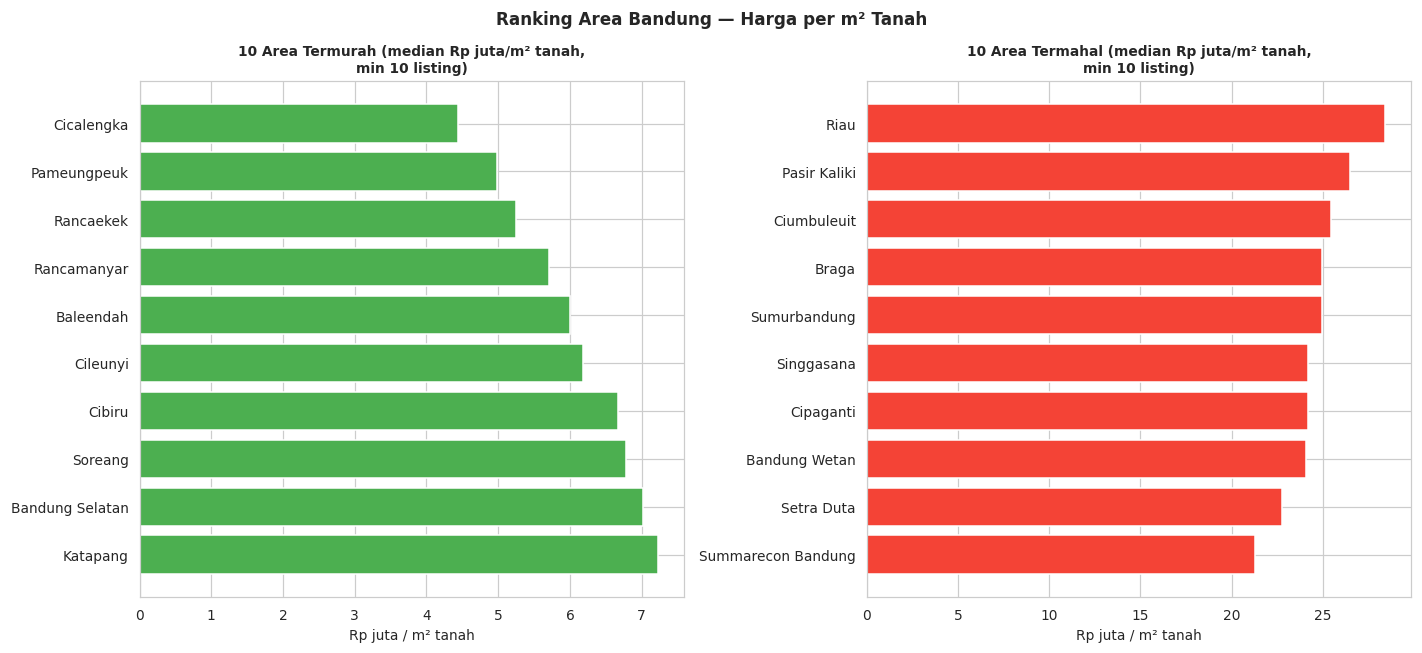

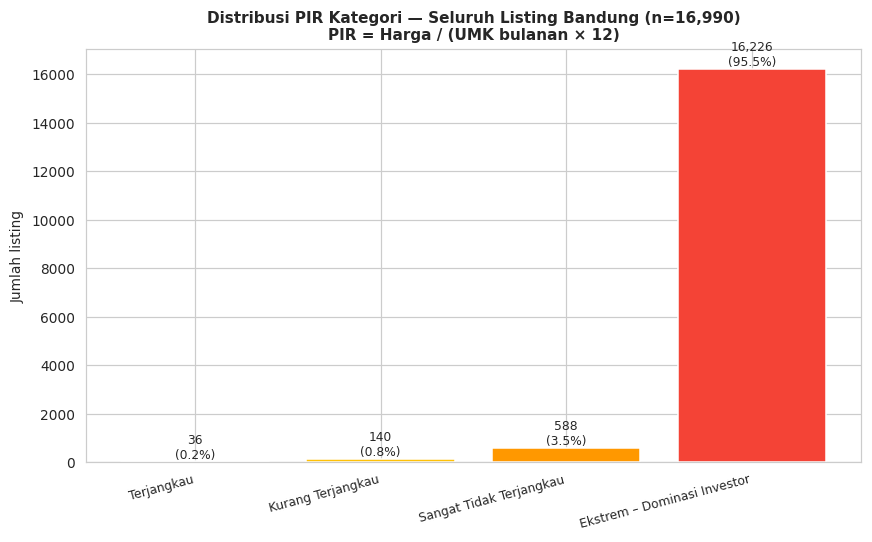

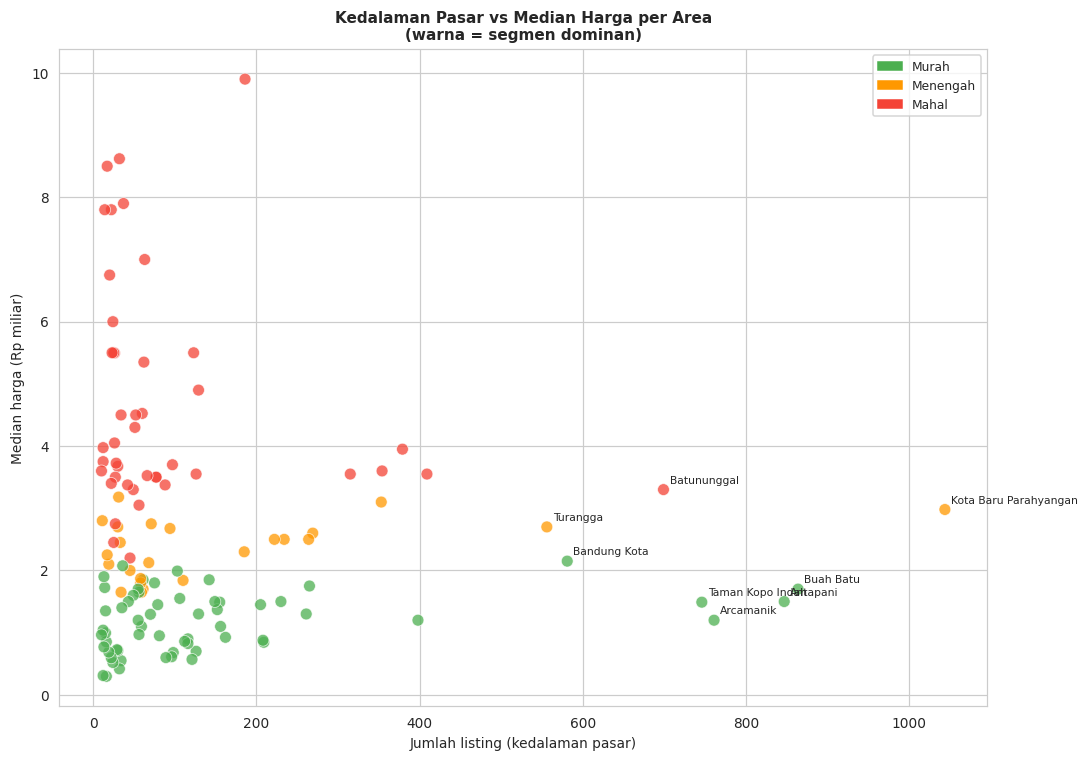

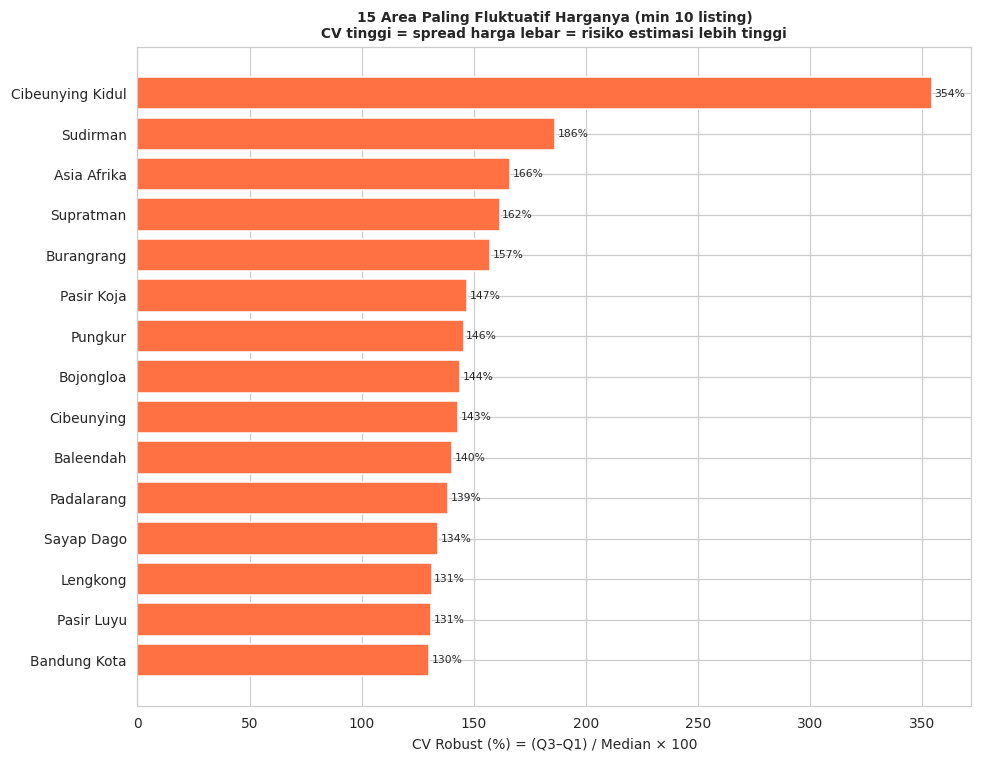

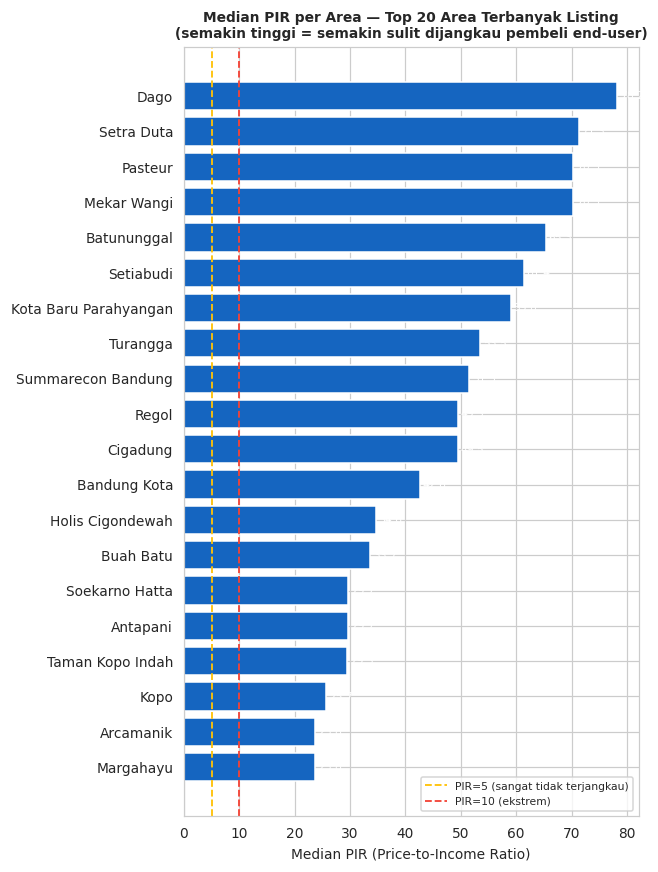


✅ STAGE 4 SELESAI. Output tersimpan di /kaggle/working/
 
File dihasilkan:
  agregasi_per_area_bandung.csv   ← statistik lengkap per area (161 area)
  listing_bandung_clean.csv        ← data bersih + flag outlier + skor rekonstruksi
  vizE_area_termurah_termahal.png  ← ranking area berdasarkan Rp/m² tanah
  vizF_distribusi_PIR.png          ← sebaran keterjangkauan (PIR) seluruh Bandung
  vizG_kedalaman_vs_harga.png      ← scatter kedalaman pasar vs harga per area
  vizH_fluktuasi_area.png          ← 15 area paling berisiko (fluktuasi harga tinggi)
  vizI_PIR_per_area.png            ← PIR per area untuk top 20 area
 
CATATAN SEBELUM INTERPRETASI:
  • 839 baris outlier_dimensi=True TIDAK dihapus dari listing_bandung_clean.csv
    → filter sendiri: df_bersih = df[~df['outlier_dimensi']]
  • 11 baris score_price_flag != 'ok_reconstructed' → cek kolom score_price_flag
  • Ranking area menggunakan min 10 listing per area agar adil
  • PIR dihitung dengan UMK konstan satu angka untuk seluruh

In [16]:
# ──────────────────────────────────────────────────────────────────────
# CELL 16 — JOIN KONTEKS MAKRO + VISUALISASI
# ──────────────────────────────────────────────────────────────────────
 
# ── 16A: Load data makro dari Stage 2/3 ─────────────────────────────────
def load_csv_jika_ada(filename):
    path = f'{KAGGLE_OUTPUT_DIR}/{filename}'
    if os.path.exists(path):
        print(f"✅ Memuat {filename}")
        return pd.read_csv(path)
    print(f"⚠️  {filename} tidak ditemukan — bagian ini dilewati")
    return None
 
# Coba dari memori dulu, fallback ke CSV
master_df = globals().get('master', load_csv_jika_ada('master_analitik.csv'))
skor_df   = globals().get('hasil',  load_csv_jika_ada('skor_komposit_kota_tipe.csv'))
 
if master_df is not None:
    bdg = master_df[master_df['Kota']=='Bandung']
    if len(bdg) > 0:
        terbaru = bdg[bdg['ihpr_yoy'].notna()].sort_values(['Tahun','kuartal_num']).tail(3)
        print(f"\n{'='*110}\nKONTEKS MAKRO BANDUNG (3 kuartal terakhir per Tipe)\n{'='*110}")
        print(terbaru[['Tipe','periode','ihpr_yoy','real_ihpr_growth','posisi_siklus','ekon_prop_gap']].to_string(index=False))
 
if skor_df is not None:
    sb = skor_df[skor_df['Kota']=='Bandung']
    if len(sb) > 0:
        print(f"\n{'='*110}\nSKOR KOMPOSIT BANDUNG per Tipe (dari Stage 3)\n{'='*110}")
        print(sb[['Tipe','SKOR_KOMPOSIT','Rank_Utama','rank_rata2','rank_std']].to_string(index=False))
 
 
# ── 16B: VISUALISASI ─────────────────────────────────────────────────────
 
# VIZ E: 10 area termurah vs termahal (median Rp/m² tanah)
fig, axes = plt.subplots(1, 2, figsize=(13, 6))
mahal = agg_rank.nlargest(10, 'median_price_per_land').sort_values('median_price_per_land')
murah = agg_rank.nsmallest(10, 'median_price_per_land').sort_values('median_price_per_land', ascending=False)
axes[0].barh(murah['area'], murah['median_price_per_land']/1e6, color='#4CAF50')
axes[0].set_title(f'10 Area Termurah (median Rp juta/m² tanah,\nmin {MIN_LIST} listing)', fontsize=9, fontweight='bold')
axes[0].set_xlabel('Rp juta / m² tanah')
axes[1].barh(mahal['area'], mahal['median_price_per_land']/1e6, color='#F44336')
axes[1].set_title(f'10 Area Termahal (median Rp juta/m² tanah,\nmin {MIN_LIST} listing)', fontsize=9, fontweight='bold')
axes[1].set_xlabel('Rp juta / m² tanah')
plt.suptitle('Ranking Area Bandung — Harga per m² Tanah', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{KAGGLE_OUTPUT_DIR}/vizE_area_termurah_termahal.png', bbox_inches='tight')
plt.show(); plt.close()
 
 
# VIZ F: Distribusi PIR kategori
fig, ax = plt.subplots(figsize=(8, 5))
order_pir = ['Terjangkau (≤3)', 'Kurang Terjangkau (3–5)',
             'Sangat Tidak Terjangkau (5–10)', 'Ekstrem – Dominasi Investor (>10)']
counts = df['PIR_kategori'].value_counts().reindex(order_pir).fillna(0)
bars = ax.bar(range(len(counts)), counts.values,
              color=['#4CAF50','#FFC107','#FF9800','#F44336'])
ax.set_xticks(range(len(counts)))
ax.set_xticklabels([c.split(' (')[0] for c in counts.index], rotation=15, ha='right', fontsize=8)
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, val,
            f'{val:,.0f}\n({val/len(df)*100:.1f}%)',
            ha='center', va='bottom', fontsize=8)
ax.set_ylabel('Jumlah listing')
ax.set_title(f'Distribusi PIR Kategori — Seluruh Listing Bandung (n={len(df):,})\n'
             f'PIR = Harga / (UMK bulanan × 12)', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{KAGGLE_OUTPUT_DIR}/vizF_distribusi_PIR.png', bbox_inches='tight')
plt.show(); plt.close()
 
 
# VIZ G: Scatter kedalaman pasar vs median harga per area
fig, ax = plt.subplots(figsize=(10, 7))
colors_map = {'Murah':'#4CAF50', 'Menengah':'#FF9800', 'Mahal':'#F44336'}
ax.scatter(agg_rank['jumlah_listing'], agg_rank['median_price']/1e9,
           c=agg_rank['segmen_dominan'].map(colors_map).fillna('#999'),
           s=60, alpha=0.75, edgecolors='white', linewidth=0.5)
for _, row in agg_rank.nlargest(8, 'jumlah_listing').iterrows():
    ax.annotate(row['area'], (row['jumlah_listing'], row['median_price']/1e9),
                fontsize=7, xytext=(4, 4), textcoords='offset points')
ax.set_xlabel('Jumlah listing (kedalaman pasar)')
ax.set_ylabel('Median harga (Rp miliar)')
ax.set_title('Kedalaman Pasar vs Median Harga per Area\n(warna = segmen dominan)', fontsize=10, fontweight='bold')
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=c, label=l) for l,c in colors_map.items()], fontsize=8)
plt.tight_layout()
plt.savefig(f'{KAGGLE_OUTPUT_DIR}/vizG_kedalaman_vs_harga.png', bbox_inches='tight')
plt.show(); plt.close()
 
 
# VIZ H: 15 area paling fluktuatif (CV robust)
fig, ax = plt.subplots(figsize=(9, 7))
fluktuatif = agg_rank.nlargest(15, 'cv_robust_pct').sort_values('cv_robust_pct')
bars = ax.barh(fluktuatif['area'], fluktuatif['cv_robust_pct'], color='#FF7043')
for bar, val in zip(bars, fluktuatif['cv_robust_pct']):
    ax.text(val + 1, bar.get_y() + bar.get_height()/2, f'{val:.0f}%', va='center', fontsize=7)
ax.set_xlabel('CV Robust (%) = (Q3–Q1) / Median × 100')
ax.set_title(f'15 Area Paling Fluktuatif Harganya (min {MIN_LIST} listing)\n'
             f'CV tinggi = spread harga lebar = risiko estimasi lebih tinggi', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{KAGGLE_OUTPUT_DIR}/vizH_fluktuasi_area.png', bbox_inches='tight')
plt.show(); plt.close()
 
 
# VIZ I: Heatmap median PIR per area — top 20 area terbesar
fig, ax = plt.subplots(figsize=(6, 8))
top20 = agg_rank.nlargest(20, 'jumlah_listing').sort_values('median_PIR', ascending=False)
bars = ax.barh(top20['area'][::-1], top20['median_PIR'][::-1], color='#1565C0')
ax.axvline(5, color='#FFC107', linewidth=1.2, linestyle='--', label='PIR=5 (sangat tidak terjangkau)')
ax.axvline(10, color='#F44336', linewidth=1.2, linestyle='--', label='PIR=10 (ekstrem)')
for bar, val in zip(bars, top20['median_PIR'][::-1]):
    ax.text(val+0.5, bar.get_y()+bar.get_height()/2, f'{val:.1f}', va='center', fontsize=7, color='white' if val>5 else 'black')
ax.set_xlabel('Median PIR (Price-to-Income Ratio)')
ax.set_title('Median PIR per Area — Top 20 Area Terbanyak Listing\n'
             '(semakin tinggi = semakin sulit dijangkau pembeli end-user)', fontsize=9, fontweight='bold')
ax.legend(fontsize=7, loc='lower right')
plt.tight_layout()
plt.savefig(f'{KAGGLE_OUTPUT_DIR}/vizI_PIR_per_area.png', bbox_inches='tight')
plt.show(); plt.close()
 
print(f"""
✅ STAGE 4 SELESAI. Output tersimpan di {KAGGLE_OUTPUT_DIR}/
 
File dihasilkan:
  agregasi_per_area_bandung.csv   ← statistik lengkap per area (161 area)
  listing_bandung_clean.csv        ← data bersih + flag outlier + skor rekonstruksi
  vizE_area_termurah_termahal.png  ← ranking area berdasarkan Rp/m² tanah
  vizF_distribusi_PIR.png          ← sebaran keterjangkauan (PIR) seluruh Bandung
  vizG_kedalaman_vs_harga.png      ← scatter kedalaman pasar vs harga per area
  vizH_fluktuasi_area.png          ← 15 area paling berisiko (fluktuasi harga tinggi)
  vizI_PIR_per_area.png            ← PIR per area untuk top 20 area
 
CATATAN SEBELUM INTERPRETASI:
  • 839 baris outlier_dimensi=True TIDAK dihapus dari listing_bandung_clean.csv
    → filter sendiri: df_bersih = df[~df['outlier_dimensi']]
  • 11 baris score_price_flag != 'ok_reconstructed' → cek kolom score_price_flag
  • Ranking area menggunakan min {MIN_LIST} listing per area agar adil
  • PIR dihitung dengan UMK konstan satu angka untuk seluruh Bandung — verifikasi
    apakah itu UMK Kota Bandung atau ada campuran wilayah kabupaten
""")